# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia and therefore YLDs.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import vivarium.gbd_mapping as gbd_mapping
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from db_queries import get_ids
import warnings
from lsff_utils import config_utils
from lsff_utils import gbd_data
from lsff_utils.hemoglobin_distribution import (
    hemoglobin_pdf_from_mean_sd,
    hemoglobin_cdf_from_mean_sd,
)

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "india"
vehicle = "rice"

In [5]:
# Parameters
location = "nigeria"
vehicle = "rice"


In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
# GBD estimation year every pull below uses. Owned by gbd_data; shown here
# so a run's output records which year it was built against.
gbd_data.most_recent_year()

2023

In [8]:
# Save the set of draws used in gbd_data when pulling modelable entities
# so we can make sure to use the same draws for the sequela prevalences
# below
DRAWS = gbd_data.DRAWS
len(DRAWS)

250

In [9]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [10]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [11]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [12]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [13]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.224398,intervention
1,1,Male,0.224398,intervention
2,2,Female,0.299197,intervention
3,2,Male,0.299197,intervention
4,3,Female,0.364646,intervention
5,3,Male,0.364646,intervention
6,4,Female,0.422749,intervention
7,4,Male,0.422749,intervention
8,5,Female,0.451467,intervention
9,5,Male,0.451467,intervention


In [14]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [15]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.224398,intervention,0,125
1,1,Male,0.224398,intervention,0,125
2,2,Female,0.299197,intervention,0,125
3,2,Male,0.299197,intervention,0,125
4,3,Female,0.364646,intervention,0,125
5,3,Male,0.364646,intervention,0,125
6,4,Female,0.422749,intervention,0,125
7,4,Male,0.422749,intervention,0,125
8,5,Female,0.451467,intervention,0,125
9,5,Male,0.451467,intervention,0,125


In [16]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [17]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  18793.149621
                               2                  17830.620200
                               3                  16129.662368
                               4                  14114.028154
                               5                  12208.445301
                                                      ...     
Male    95.0       125.000000  1                   4849.649774
                               2                   4371.181536
                               3                   4569.918352
                               4                   4550.906874
                               5                   5750.658068
Name: value, Length: 250, dtype: float64

In [18]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [19]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

9984802.005639391

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

1252305.782830505

In [21]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

7562913.436395377

In [22]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [23]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [24]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [25]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [26]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [27]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.to_frame()
            .assign(sex="Female")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.to_frame()
            .assign(sex="Male")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [28]:
effective_coverage_intervention = effective_coverage_intervention.reorder_levels(
    ["sex", "age_start", "age_end", "wealth_quintile", "scenario"]
)

In [29]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [30]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.224398
Name: value, dtype: float64

## Pull GBD hemoglobin distribution statistics

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

# Verify the MEIDs against get_ids
meids_df = get_ids('modelable_entity')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_mean"],
        'modelable_entity_name'].squeeze()
        == 'Mean Hemoglobin (g/L, elevation adjusted) - Custom')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_sd"],
        'modelable_entity_name'].squeeze()
        == 'Standard Deviation of Hemoglobin (g/L, survey elevation adjusted)')
# Model versions pinned explicitly. Passing version_id skips vivarium_gbd_access's
# version resolution, which goes through rotisserie -- and rotisserie has no
# rotation context for these custom MEs (RotisserieNotFoundError). Recovered from a
# warm cache, so these are whatever was current then; revisit when the round moves.
me_version_ids = {
    "hemoglobin_mean": 882457,
    "hemoglobin_sd": 882401,
}

In [32]:
gbd_hgb_mean = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_mean"], location, version_id=me_version_ids["hemoglobin_mean"]
)
gbd_hgb_mean

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/base/utils.py:159: RemovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  session.execute(


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.966535  143.650481  133.997407  148.190371   
       0.019178  0.076712    134.006805  127.512643  118.944006  131.542517   
       0.076712  0.500000    109.241985  103.947961   96.962831  107.233104   
       0.500000  1.000000    103.694886  103.682815   98.315023  103.747742   
       1.000000  2.000000    101.511831  104.165424   98.846623  101.995650   
       2.000000  5.000000    104.916754  109.845023  104.383710  106.871336   
       5.000000  10.000000   123.272286  117.298335  109.416082  121.005399   
       10.000000 15.000000   126.642119  120.610383  112.619832  124.402089   
       15.000000 20.000000   118.227214  121.866247  115.827596  119.089232   
       20.000000 25.000000   118.968611  122.123275  115.996842  119.790549   
       25.000000 30.000000   119.861264  123.347475  117.277224  120.837675   
       30.000000 35.000000   119.384428  121.659763  115.701678  120.277687   
       35.000000 40.000000   119.445220  121.926524  115.779217  120.042509   
       40.000000 45.000000   119.831319  121.629345  115.347956  120.269489   
       45.000000 50.000000   121.704726  122.854424  116.633593  122.508448   
       50.000000 55.000000   129.174888  122.914887  114.655212  126.799455   
       55.000000 60.000000   130.115834  123.810234  115.490393  127.723099   
       60.000000 65.000000   130.868195  124.526135  116.158186  128.461624   
       65.000000 70.000000   131.234233  124.874434  116.483080  128.820931   
       70.000000 75.000000   132.076356  125.675746  117.230545  129.647568   
       75.000000 80.000000   130.841224  124.500470  116.134246  128.435148   
       80.000000 85.000000   130.736069  124.400411  116.040911  128.331927   
       85.000000 90.000000   130.353796  124.036664  115.701606  127.956684   
       90.000000 95.000000   127.510665  121.331316  113.178053  125.165837   
       95.000000 125.000000  125.441553  119.362476  111.341516  123.134774   
Male   0.000000  0.019178    156.588432  149.302409  139.665609  153.825399   
       0.019178  0.076712    133.015174  126.826008  118.639959  130.668095   
       0.076712  0.500000    107.376553  102.380347   95.772156  105.481873   
       0.500000  1.000000    103.116685  100.955157   95.954311  102.732580   
       1.000000  2.000000    101.306006  100.983658   95.990736  101.285462   
       2.000000  5.000000    104.606000  108.148971  102.732963  105.015538   
       5.000000  10.000000   123.340264  117.601270  110.010636  121.163901   
       10.000000 15.000000   131.025597  124.929006  116.865400  128.713625   
       15.000000 20.000000   144.468172  137.746101  128.855209  141.919003   
       20.000000 25.000000   148.986555  142.054245  132.885282  146.357658   
       25.000000 30.000000   148.905019  141.976503  132.812557  146.277561   
       30.000000 35.000000   150.431806  143.432249  134.174342  147.777408   
       35.000000 40.000000   153.550609  146.405934  136.956089  150.841178   
       40.000000 45.000000   153.352345  146.216896  136.779252  150.646413   
       45.000000 50.000000   151.777246  144.715086  135.374378  149.099107   
       50.000000 55.000000   150.238388  143.247831  134.001827  147.587403   
       55.000000 60.000000   147.906503  141.024448  131.921953  145.296664   
       60.000000 65.000000   145.847334  139.061092  130.085323  143.273830   
       65.000000 70.000000   141.482410  134.899266  126.192124  138.985925   
       70.000000 75.000000   137.258596  130.871986  122.424787  134.836642   
       75.000000 80.000000   131.279762  125.171346  117.092098  128.963306   
       80.000000 85.000000   126.718828  120.822630  113.024072  124.482849   
       85.000000 90.000000   121.493846  115.840766  108.363765  119.350064   
       90.000000 95.000000   115.465006  110.092446  102.986473  113.427604   
    

In [33]:
gbd_hgb_mean.loc[("Female", 25, 30)].mean()

118.96045746053272

In [34]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  104.018019
                               2                  104.915748
                               3                  106.181659
                               4                  108.014151
                               5                  110.057035
                                                     ...    
Male    95.0       125.000000  1                  120.287850
                               2                  120.813131
                               3                  121.639186
                               4                  122.277309
                               5                  122.383162
Name: value, Length: 250, dtype: float64

In [35]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.237660,0.225487,0.203977,0.178487,0.154389
1,Female,5.0,15.0,not_pregnant,0.222657,0.219831,0.200573,0.188057,0.168882
2,Female,15.0,30.0,not_pregnant,0.165585,0.191566,0.209803,0.226150,0.206896
3,Female,15.0,30.0,pregnant,0.228131,0.261971,0.225828,0.174600,0.109470
4,Female,30.0,50.0,not_pregnant,0.169298,0.173463,0.186056,0.208814,0.262369
5,Female,30.0,50.0,pregnant,0.231282,0.190765,0.171661,0.205521,0.200770
6,Female,50.0,125.0,not_pregnant,0.183495,0.183221,0.202734,0.200921,0.229630
7,Male,0.0,5.0,not_pregnant,0.245259,0.222780,0.202629,0.173367,0.155965
8,Male,5.0,15.0,not_pregnant,0.227679,0.210604,0.201929,0.192289,0.167499
9,Male,15.0,30.0,not_pregnant,0.171533,0.196784,0.207765,0.218414,0.205504


In [36]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.237660
                               2                  0.225487
                               3                  0.203977
                               4                  0.178487
                               5                  0.154389
                                                    ...   
Male    95.0       125.000000  1                  0.201294
                               2                  0.181435
                               3                  0.189684
                               4                  0.188895
                               5                  0.238693
Name: value, Length: 250, dtype: float64

In [37]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [38]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [39]:
hgb_mean = distribute_by_disparities(gbd_hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.966535  143.650481  133.997407  148.190371   
       0.019178  0.076712    134.006805  127.512643  118.944006  131.542517   
       0.076712  0.500000    109.241985  103.947961   96.962831  107.233104   
       0.500000  1.000000    103.694886  103.682815   98.315023  103.747742   
       1.000000  2.000000    101.511831  104.165424   98.846623  101.995650   
       2.000000  5.000000    104.916754  109.845023  104.383710  106.871336   
       5.000000  10.000000   123.272286  117.298335  109.416082  121.005399   
       10.000000 15.000000   126.642119  120.610383  112.619832  124.402089   
       15.000000 20.000000   118.227214  121.866247  115.827596  119.089232   
       20.000000 25.000000   118.968611  122.123275  115.996842  119.790549   
       25.000000 30.000000   119.861264  123.347475  117.277224  120.837675   
       30.000000 35.000000   119.384428  121.659763  115.701678  120.277687   
       35.000000 40.000000   119.445220  121.926524  115.779217  120.042509   
       40.000000 45.000000   119.831319  121.629345  115.347956  120.269489   
       45.000000 50.000000   121.704726  122.854424  116.633593  122.508448   
       50.000000 55.000000   129.174888  122.914887  114.655212  126.799455   
       55.000000 60.000000   130.115834  123.810234  115.490393  127.723099   
       60.000000 65.000000   130.868195  124.526135  116.158186  128.461624   
       65.000000 70.000000   131.234233  124.874434  116.483080  128.820931   
       70.000000 75.000000   132.076356  125.675746  117.230545  129.647568   
       75.000000 80.000000   130.841224  124.500470  116.134246  128.435148   
       80.000000 85.000000   130.736069  124.400411  116.040911  128.331927   
       85.000000 90.000000   130.353796  124.036664  115.701606  127.956684   
       90.000000 95.000000   127.510665  121.331316  113.178053  125.165837   
       95.000000 125.000000  125.441553  119.362476  111.341516  123.134774   
Male   0.000000  0.019178    156.588432  149.302409  139.665609  153.825399   
       0.019178  0.076712    133.015174  126.826008  118.639959  130.668095   
       0.076712  0.500000    107.376553  102.380347   95.772156  105.481873   
       0.500000  1.000000    103.116685  100.955157   95.954311  102.732580   
       1.000000  2.000000    101.306006  100.983658   95.990736  101.285462   
       2.000000  5.000000    104.606000  108.148971  102.732963  105.015538   
       5.000000  10.000000   123.340264  117.601270  110.010636  121.163901   
       10.000000 15.000000   131.025597  124.929006  116.865400  128.713625   
       15.000000 20.000000   144.468172  137.746101  128.855209  141.919003   
       20.000000 25.000000   148.986555  142.054245  132.885282  146.357658   
       25.000000 30.000000   148.905019  141.976503  132.812557  146.277561   
       30.000000 35.000000   150.431806  143.432249  134.174342  147.777408   
       35.000000 40.000000   153.550609  146.405934  136.956089  150.841178   
       40.000000 45.000000   153.352345  146.216896  136.779252  150.646413   
       45.000000 50.000000   151.777246  144.715086  135.374378  149.099107   
       50.000000 55.000000   150.238388  143.247831  134.001827  147.587403   
       55.000000 60.000000   147.906503  141.024448  131.921953  145.296664   
       60.000000 65.000000   145.847334  139.061092  130.085323  143.273830   
       65.000000 70.000000   141.482410  134.899266  126.192124  138.985925   
       70.000000 75.000000   137.258596  130.871986  122.424787  134.836642   
       75.000000 80.000000   131.279762  125.171346  117.092098  128.963306   
       80.000000 85.000000   126.718828  120.822630  113.024072  124.482849   
       85.000000 90.000000   121.493846  115.840766  108.363765  119.350064   
       90.000000 95.000000   115.465006  110.092446  102.986473  113.427604   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009407  0.009407  0.009407  0.009407  0.009407   
       0.019178  0.076712    0.009407  0.009407  0.009407  0.009407  0.009407   
       0.076712  0.500000    0.009407  0.009407  0.009407  0.009407  0.009407   
       0.500000  1.000000    0.009407  0.009407  0.009407  0.009407  0.009407   
       1.000000  2.000000    0.009407  0.009407  0.009407  0.009407  0.009407   
       2.000000  5.000000    0.009407  0.009407  0.009407  0.009407  0.009407   
       5.000000  10.000000   0.008779  0.008779  0.008779  0.008779  0.008779   
       10.000000 15.000000   0.008779  0.008779  0.008779  0.008779  0.008779   
       15.000000 20.000000   0.008227  0.008227  0.008227  0.008227  0.008227   
       20.000000 25.000000   0.008227  0.008227  0.008227  0.008227  0.008227   
       25.0000

In [40]:
gbd_hgb_mean.columns.name = "draw"
gbd_hgb_mean = gbd_hgb_mean.stack().rename("mean")

In [41]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [42]:
gbd_hgb_sd = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_sd"], location, version_id=me_version_ids["hemoglobin_sd"]
)
gbd_hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    23.621065  22.215483  28.427704  15.125453   
       0.019178  0.076712    27.123463  15.906641  18.329904  17.526012   
       0.076712  0.500000    24.309039  15.094109  15.585073  16.877107   
       0.500000  1.000000    20.916076  19.628703  16.244995  18.214384   
       1.000000  2.000000    19.205029  20.909722  17.911274  18.200277   
       2.000000  5.000000    19.816279  22.756450  21.188596  20.475546   
       5.000000  10.000000   25.452569  13.914614  12.949282  17.088616   
       10.000000 15.000000   30.939697  20.600019  15.570055  22.803204   
       15.000000 20.000000   21.579375  22.760652  19.893218  18.540696   
       20.000000 25.000000   22.760269  23.941451  21.282370  19.981375   
       25.000000 30.000000   21.988581  23.455800  20.719747  19.241083   
       30.000000 35.000000   23.061750  23.685724  20.346336  20.836623   
       35.000000 40.000000   22.033548  23.556182  20.400433  19.097314   
       40.000000 45.000000   22.308178  23.037016  19.111012  18.708905   
       45.000000 50.000000   23.139494  23.035746  19.505846  19.987613   
       50.000000 55.000000   33.268652  22.614094  16.611855  24.835823   
       55.000000 60.000000   34.474839  23.763969  17.692532  25.948388   
       60.000000 65.000000   35.390745  24.626843  18.538050  26.773881   
       65.000000 70.000000   35.815396  25.030459  18.917551  27.171933   
       70.000000 75.000000   36.876939  26.047348  19.793564  28.206914   
       75.000000 80.000000   34.300588  23.595207  17.699988  25.694504   
       80.000000 85.000000   32.134002  21.388993  16.308492  23.307836   
       85.000000 90.000000   31.683473  20.913376  16.299984  22.762173   
       90.000000 95.000000   30.291060  19.615609  16.063154  21.540497   
       95.000000 125.000000  29.927858  19.622622  17.042529  21.602100   
Male   0.000000  0.019178     9.713557  10.619283  26.342881   5.385895   
       0.019178  0.076712    20.767733   9.393146  17.400520  10.167586   
       0.076712  0.500000    24.774006  15.991276  15.249446  17.709719   
       0.500000  1.000000    23.384565  20.200345  14.576443  20.707517   
       1.000000  2.000000    22.098436  22.909945  16.278799  21.263117   
       2.000000  5.000000    21.646605  23.553441  18.845936  20.419915   
       5.000000  10.000000   26.198109  14.086321  12.941044  15.621210   
       10.000000 15.000000   30.039624  18.199545  15.690825  19.125579   
       15.000000 20.000000   33.940108  22.446467  21.382560  23.098864   
       20.000000 25.000000   34.828635  23.532269  22.161507  24.389115   
       25.000000 30.000000   34.413811  23.164875  21.812009  24.039456   
       30.000000 35.000000   32.815397  22.006534  20.496299  23.074072   
       35.000000 40.000000   30.479589  20.592825  18.589938  22.035951   
       40.000000 45.000000   30.677050  20.709875  18.783031  22.116463   
       45.000000 50.000000   30.831272  20.639401  18.872160  21.967207   
       50.000000 55.000000   31.834244  21.233287  19.640471  22.426648   
       55.000000 60.000000   31.816297  20.922585  19.542479  21.987908   
       60.000000 65.000000   32.235115  20.992493  19.930108  21.848489   
       65.000000 70.000000   32.945724  21.188265  20.611375  21.723802   
       70.000000 75.000000   34.379967  22.356930  22.003699  22.529229   
       75.000000 80.000000   39.054935  28.529186  25.726509  28.913103   
       80.000000 85.000000   45.855737  37.687634  29.418411  40.602527   
       85.000000 90.000000   54.358463  50.959911  32.923384  54.999998   
       90.000000 95.000000   54.999754  54.999999  33.098108  54.999999   
       95.000000 125.000000  46.450054  50.966017  26.503584  54.999999   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [43]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14.268159
                               2                  14.307554
                               3                  13.564635
                               4                  12.328836
                               5                  11.817992
                                                    ...    
Male    95.0       125.000000  1                  16.333690
                               2                  15.425789
                               3                  14.296448
                               4                  13.826328
                               5                  13.285569
Name: value, Length: 250, dtype: float64

In [44]:
hgb_sd = distribute_by_disparities(gbd_hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    23.621065  22.215483  28.427704  15.125453   
       0.019178  0.076712    27.123463  15.906641  18.329904  17.526012   
       0.076712  0.500000    24.309039  15.094109  15.585073  16.877107   
       0.500000  1.000000    20.916076  19.628703  16.244995  18.214384   
       1.000000  2.000000    19.205029  20.909722  17.911274  18.200277   
       2.000000  5.000000    19.816279  22.756450  21.188596  20.475546   
       5.000000  10.000000   25.452569  13.914614  12.949282  17.088616   
       10.000000 15.000000   30.939697  20.600019  15.570055  22.803204   
       15.000000 20.000000   21.579375  22.760652  19.893218  18.540696   
       20.000000 25.000000   22.760269  23.941451  21.282370  19.981375   
       25.000000 30.000000   21.988581  23.455800  20.719747  19.241083   
       30.000000 35.000000   23.061750  23.685724  20.346336  20.836623   
       35.000000 40.000000   22.033548  23.556182  20.400433  19.097314   
       40.000000 45.000000   22.308178  23.037016  19.111012  18.708905   
       45.000000 50.000000   23.139494  23.035746  19.505846  19.987613   
       50.000000 55.000000   33.268652  22.614094  16.611855  24.835823   
       55.000000 60.000000   34.474839  23.763969  17.692532  25.948388   
       60.000000 65.000000   35.390745  24.626843  18.538050  26.773881   
       65.000000 70.000000   35.815396  25.030459  18.917551  27.171933   
       70.000000 75.000000   36.876939  26.047348  19.793564  28.206914   
       75.000000 80.000000   34.300588  23.595207  17.699988  25.694504   
       80.000000 85.000000   32.134002  21.388993  16.308492  23.307836   
       85.000000 90.000000   31.683473  20.913376  16.299984  22.762173   
       90.000000 95.000000   30.291060  19.615609  16.063154  21.540497   
       95.000000 125.000000  29.927858  19.622622  17.042529  21.602100   
Male   0.000000  0.019178     9.713557  10.619283  26.342881   5.385895   
       0.019178  0.076712    20.767733   9.393146  17.400520  10.167586   
       0.076712  0.500000    24.774006  15.991276  15.249446  17.709719   
       0.500000  1.000000    23.384565  20.200345  14.576443  20.707517   
       1.000000  2.000000    22.098436  22.909945  16.278799  21.263117   
       2.000000  5.000000    21.646605  23.553441  18.845936  20.419915   
       5.000000  10.000000   26.198109  14.086321  12.941044  15.621210   
       10.000000 15.000000   30.039624  18.199545  15.690825  19.125579   
       15.000000 20.000000   33.940108  22.446467  21.382560  23.098864   
       20.000000 25.000000   34.828635  23.532269  22.161507  24.389115   
       25.000000 30.000000   34.413811  23.164875  21.812009  24.039456   
       30.000000 35.000000   32.815397  22.006534  20.496299  23.074072   
       35.000000 40.000000   30.479589  20.592825  18.589938  22.035951   
       40.000000 45.000000   30.677050  20.709875  18.783031  22.116463   
       45.000000 50.000000   30.831272  20.639401  18.872160  21.967207   
       50.000000 55.000000   31.834244  21.233287  19.640471  22.426648   
       55.000000 60.000000   31.816297  20.922585  19.542479  21.987908   
       60.000000 65.000000   32.235115  20.992493  19.930108  21.848489   
       65.000000 70.000000   32.945724  21.188265  20.611375  21.723802   
       70.000000 75.000000   34.379967  22.356930  22.003699  22.529229   
       75.000000 80.000000   39.054935  28.529186  25.726509  28.913103   
       80.000000 85.000000   45.855737  37.687634  29.418411  40.602527   
       85.000000 90.000000   54.358463  50.959911  32.923384  54.999998   
       90.000000 95.000000   54.999754  54.999999  33.098108  54.999999   
       95.000000 125.000000  46.450054  50.966017  26.503584  54.999999   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.074576  0.074576  0.074576  0.074576  0.074576   
       0.019178  0.076712    0.074576  0.074576  0.074576  0.074576  0.074576   
       0.076712  0.500000    0.074576  0.074576  0.074576  0.074576  0.074576   
       0.500000  1.000000    0.074576  0.074576  0.074576  0.074576  0.074576   
       1.000000  2.000000    0.074576  0.074576  0.074576  0.074576  0.074576   
       2.000000  5.000000    0.074576  0.074576  0.074576  0.074576  0.074576   
       5.000000  10.000000   0.071183  0.071183  0.071183  0.071183  0.071183   
       10.000000 15.000000   0.071183  0.071183  0.071183  0.071183  0.071183   
       15.000000 20.000000   0.068801  0.068801  0.068801  0.068801  0.068801   
       20.000000 25.000000   0.068801  0.068801  0.068801  0.068801  0.068801   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                25.134325  23.638696  30.248897   
                            2                25.203723  23.703965  30.332417   
                            3                23.895021  22.473138  28.757408   
                            4                21.718078  20.425735  26.137480   
                            5                20.818191  19.579396  25.054475   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                52.032299  57.090979  29.688715   
                            2                49.140105  53.917600  28.038479   
                            3                45.542499  49.970228  25.985749   
                            4                44.044893  48.327021  25.131241   
                            5                42.322263  46.436914  24.148338   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                16.094450  31.678156  13.256576   
                            2                16.138889  31.765622  13.293178   
                            3                15.300877  30.116194  12.602931   
                            4                13.906899  27.372474  11.454747   
                            5                13.330668  26.238298  10.980121   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                61.609754  23.066420  40.909590   
                            2                58.185201  21.784282  38.635647   
                            3                53.925393  20.189429  35.807085   
                            4                52.152125  19.525525  34.629615   
                            5                50.112415  18.761867  33.275224   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                31.973624  31.989858  27.483369   
                            2                32.061906  32.078185  27.559253   
                            3                30.397093  30.412526  26.128240   
                            4                27.627782  27.641810  23.747840   
                            5                26.483027  26.496473  22.763851   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                30.896633  32.047885  37.834829   
                            2                29.179256  30.266516  35.731795   
                            3                27.043008  28.050668  33.115827   
                            4                26.153733  27.128258  32.026856   
                            5                25.130840  26.067251  30.774261   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                23.550654  31.713354  29.989606   
                            2                23.615679  31.800918  30.072410   
                            3                22.389436  30.149656  28.510901   
                            4                20.349659  27.402888  25.913431   
                            5                19.506472  26.267452  24.839710   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                29.516030  29.580069  38.610902   
                            2                27.875393  27.935873  36.464730   
                            3                25.834602  25.890654  33.795104   
                            4                

In [45]:
gbd_hgb_sd.columns.name = "draw"
gbd_hgb_sd = gbd_hgb_sd.stack().rename("sd")
gbd_hgb_sd

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      23.621065
                               draw_1      22.215483
                               draw_2      28.427704
                               draw_3      15.125453
                               draw_4      29.770912
                                             ...    
Male    95.0       125.000000  draw_245    37.722073
                               draw_246    54.999999
                               draw_247    54.999999
                               draw_248    54.999999
                               draw_249    24.476821
Name: sd, Length: 12500, dtype: float64

In [46]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      25.134325
                                                draw_1      23.638696
                                                draw_2      30.248897
                                                draw_3      16.094450
                                                draw_4      31.678156
                                                              ...    
Male    95.0       125.000000  5                draw_245    34.369895
                                                draw_246    50.112415
                                                draw_247    50.112415
                                                draw_248    50.112415
                                                draw_249    22.301684
Name: sd, Length: 62500, dtype: float64

In [47]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

117.71994862194255

In [48]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

19.751761941392083

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [49]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [50]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [51]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [52]:
len(iron_responsive_anemia_sequelae)

138

In [53]:
len(non_iron_responsive_anemia_sequelae)

60

In [54]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # Without quieting the logs, there were tons of validation warnings
    # Look into these more?
    with gbd_data.quiet_gbd_logs():
        for sequela in sequelae:
            try:
                sequela_prevalence = vivarium_inputs.get_measure(
                    sequela, "prevalence", location.title()
                ).droplevel(["location"])
            # There are even some errors, caused by all-zero values
            except DataDoesNotExistError as e:
                assert "zero" in str(e)
                continue
            except DataAbnormalError as e:
                assert "zero" in str(e)
                continue

            # AFAIK these are not mutually exclusive; standard GBD assumption is independence
            result += sequela_prevalence * (1 - result)

    return result

In [55]:
# GBD 2023's Global population trips a stale ceiling in vivarium_inputs.
# See lsff_utils.gbd_data for why, and for the TODO to remove it.
gbd_data.patch_population_validation_ceiling()

with gbd_data.quiet_gbd_logs():
    global_population = (
        vivarium_inputs.get_population_structure("Global").droplevel("location").value
    )
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2023        2024        1.169382e+06
        0.019178   0.076712    2023        2024        3.484011e+06
        0.076712   0.500000    2023        2024        2.565567e+07
        0.500000   1.000000    2023        2024        3.009545e+07
        1.000000   2.000000    2023        2024        6.090771e+07
        2.000000   5.000000    2023        2024        1.904133e+08
        5.000000   10.000000   2023        2024        3.394829e+08
        10.000000  15.000000   2023        2024        3.312048e+08
        15.000000  20.000000   2023        2024        3.140986e+08
        20.000000  25.000000   2023        2024        2.965056e+08
        25.000000  30.000000   2023        2024        2.896126e+08
        30.000000  35.000000   2023        2024        2.944150e+08
        35.000000  40.000000   2023        2024        2.882803e+08
        40.000000  45.000000   2023        2024        2.551532e

In [56]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

quiet_gbd_logs: 60 data-quality warning(s) from vivarium_inputs, 1 distinct:
      60x  Data returned extra columns: {'version_id'}.
  Set gbd_data.DEFAULT_VERBOSITY = gbd_data.Verbosity.WARNINGS to see these live, or Verbosity.QUIET to stop reporting them.


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.045578  0.046219  0.045671   
       0.019178  0.076712   2023       2024      0.049863  0.043073  0.045211   
       0.076712  0.500000   2023       2024      0.050801  0.045918  0.047161   
       0.500000  1.000000   2023       2024      0.047583  0.043008  0.044856   
       1.000000  2.000000   2023       2024      0.048627  0.045214  0.046868   
       2.000000  5.000000   2023       2024      0.046250  0.046825  0.047068   
       5.000000  10.000000  2023       2024      0.055045  0.046194  0.052140   
       10.000000 15.000000  2023       2024      0.053610  0.035507  0.044549   
       15.000000 20.000000  2023       2024      0.053701  0.049667  0.053160   
       20.000000 25.000000  2023       2024      0.053737  0.049797  0.050895   
       25.000000 30.000000  2023       2024      0.051301  0.048516  0.048960   
       30.000000 35.000000  2023       2024      0.048301  0.046825  0.046768   
       35.000000 40.000000  2023       2024      0.047374  0.045653  0.046068   
       40.000000 45.000000  2023       2024      0.047406  0.045043  0.046064   
       45.000000 50.000000  2023       2024      0.043932  0.040883  0.044057   
       50.000000 55.000000  2023       2024      0.043830  0.034350  0.040878   
       55.000000 60.000000  2023       2024      0.039881  0.030024  0.038494   
       60.000000 65.000000  2023       2024      0.049342  0.038222  0.049550   
       65.000000 70.000000  2023       2024      0.045641  0.036414  0.047796   
       70.000000 75.000000  2023       2024      0.042886  0.035202  0.042215   
       75.000000 80.000000  2023       2024      0.045523  0.036062  0.043701   
       80.000000 85.000000  2023       2024      0.042347  0.033395  0.041462   
       85.000000 90.000000  2023       2024      0.036577  0.029210  0.036895   
       90.000000 95.000000  2023       2024      0.036727  0.029834  0.040546   
       95.000000 125.000000 2023       2024      0.034179  0.027805  0.038146   
Male   0.000000  0.019178   2023       2024      0.043624  0.055535  0.045043   
       0.019178  0.076712   2023       2024      0.052826  0.055795  0.050590   
       0.076712  0.500000   2023       2024      0.050557  0.048097  0.050579   
       0.500000  1.000000   2023       2024      0.048093  0.044355  0.047949   
       1.000000  2.000000   2023       2024      0.050922  0.047092  0.046134   
       2.000000  5.000000   2023       2024      0.053707  0.047777  0.046216   
       5.000000  10.000000  2023       2024      0.060280  0.048688  0.053154   
       10.000000 15.000000  2023       2024      0.049842  0.031900  0.039663   
       15.000000 20.000000  2023       2024      0.042560  0.037473  0.041824   
       20.000000 25.000000  2023       2024      0.032605  0.029675  0.032322   
       25.000000 30.000000  2023       2024      0.029532  0.027868  0.030337   
       30.000000 35.000000  2023       2024      0.027871  0.025995  0.028755   
       35.000000 40.000000  2023       2024      0.027544  0.026161  0.028791   
       40.000000 45.000000  2023       2024      0.029782  0.027342  0.030236   
       45.000000 50.000000  2023       2024      0.030540  0.027853  0.030807   
       50.000000 55.000000  2023       2024      0.031237  0.029062  0.030689   
       55.000000 60.000000  2023       2024      0.032731  0.028127  0.034992   
       60.000000 65.000000  2023       2024      0.037746  0.033909  0.041938   
       65.000000 70.000000  2023       2024      0.039095  0.034342  0.042015   
       70.000000 75.000000  2023       2024      0.040174  0.035720  0.042459   
       75.000000 80.000000  2023       2024      0.044304  0.041342  0.045814   
       80.000000 85.000000  2023       2024      0.043023  0.041786  0.046412   
       85.000000 90.000000  2023       2024      0.049052  0.043388  0.047786   
 

In [57]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.043705
draw_1      0.038003
draw_2      0.042088
draw_3      0.045451
draw_4      0.040852
              ...   
draw_245    0.038835
draw_246    0.032406
draw_247    0.034347
draw_248    0.035604
draw_249    0.034705
Length: 250, dtype: float64

In [58]:
global_non_responsive_aggregated.describe()

count    250.000000
mean       0.039116
std        0.004677
min        0.030456
25%        0.035535
50%        0.038269
75%        0.042047
max        0.056658
dtype: float64

In [59]:
global_non_responsive_aggregated.mean()

0.039116124438922525

In [60]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.398533
draw_1      3.378390
draw_2      3.392796
draw_3      3.404750
draw_4      3.388423
              ...   
draw_245    3.381314
draw_246    3.358848
draw_247    3.365598
draw_248    3.369983
draw_249    3.366847
Length: 250, dtype: float64

In [61]:
hemoglobin_effect_among_responsive.mean()

3.382382636570992

## Iron-responsiveness in population of interest

In [62]:
# This call would emit lots of warnings and log messages without the
# quiet_gbd_logs context manager in pull_sequelae_prevalence.
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

quiet_gbd_logs: 57 data-quality warning(s) from vivarium_inputs, 1 distinct:
      57x  Data returned extra columns: {'version_id'}.
  Set gbd_data.DEFAULT_VERBOSITY = gbd_data.Verbosity.WARNINGS to see these live, or Verbosity.QUIET to stop reporting them.


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.066737  0.082084  0.067536   
       0.019178  0.076712   2023       2024      0.120351  0.121402  0.101294   
       0.076712  0.500000   2023       2024      0.128158  0.137253  0.121561   
       0.500000  1.000000   2023       2024      0.169756  0.127266  0.145554   
       1.000000  2.000000   2023       2024      0.172884  0.138212  0.156248   
       2.000000  5.000000   2023       2024      0.156477  0.145213  0.168219   
       5.000000  10.000000  2023       2024      0.274318  0.160009  0.227766   
       10.000000 15.000000  2023       2024      0.205689  0.101090  0.160076   
       15.000000 20.000000  2023       2024      0.185192  0.149110  0.165092   
       20.000000 25.000000  2023       2024      0.167391  0.138658  0.145145   
       25.000000 30.000000  2023       2024      0.162976  0.138017  0.140799   
       30.000000 35.000000  2023       2024      0.170779  0.138306  0.147764   
       35.000000 40.000000  2023       2024      0.187472  0.159141  0.152189   
       40.000000 45.000000  2023       2024      0.193574  0.165441  0.154890   
       45.000000 50.000000  2023       2024      0.197485  0.146224  0.161073   
       50.000000 55.000000  2023       2024      0.178605  0.104323  0.145185   
       55.000000 60.000000  2023       2024      0.165034  0.097322  0.136923   
       60.000000 65.000000  2023       2024      0.164262  0.106307  0.146908   
       65.000000 70.000000  2023       2024      0.150065  0.100966  0.137579   
       70.000000 75.000000  2023       2024      0.132110  0.092731  0.123576   
       75.000000 80.000000  2023       2024      0.140027  0.094824  0.127126   
       80.000000 85.000000  2023       2024      0.141682  0.092060  0.125019   
       85.000000 90.000000  2023       2024      0.140530  0.090722  0.123878   
       90.000000 95.000000  2023       2024      0.153641  0.096599  0.134868   
       95.000000 125.000000 2023       2024      0.143564  0.095399  0.133127   
Male   0.000000  0.019178   2023       2024      0.068403  0.127866  0.072999   
       0.019178  0.076712   2023       2024      0.103717  0.165117  0.100471   
       0.076712  0.500000   2023       2024      0.127115  0.130041  0.120774   
       0.500000  1.000000   2023       2024      0.145301  0.108392  0.142687   
       1.000000  2.000000   2023       2024      0.156702  0.127303  0.148953   
       2.000000  5.000000   2023       2024      0.152178  0.133525  0.153950   
       5.000000  10.000000  2023       2024      0.230964  0.156183  0.198704   
       10.000000 15.000000  2023       2024      0.212598  0.099785  0.138923   
       15.000000 20.000000  2023       2024      0.139742  0.085475  0.111158   
       20.000000 25.000000  2023       2024      0.109642  0.070929  0.092150   
       25.000000 30.000000  2023       2024      0.108937  0.072257  0.091803   
       30.000000 35.000000  2023       2024      0.106278  0.069584  0.091977   
       35.000000 40.000000  2023       2024      0.093165  0.061874  0.086646   
       40.000000 45.000000  2023       2024      0.093854  0.062696  0.086890   
       45.000000 50.000000  2023       2024      0.102085  0.066825  0.091247   
       50.000000 55.000000  2023       2024      0.109723  0.070820  0.095675   
       55.000000 60.000000  2023       2024      0.122808  0.077020  0.103929   
       60.000000 65.000000  2023       2024      0.134419  0.088150  0.117512   
       65.000000 70.000000  2023       2024      0.148686  0.100917  0.125393   
       70.000000 75.000000  2023       2024      0.153248  0.110519  0.126534   
       75.000000 80.000000  2023       2024      0.134380  0.105299  0.119372   
       80.000000 85.000000  2023       2024      0.110681  0.092928  0.114923   
       85.000000 90.000000  2023       2024      0.100732  0.086473  0.114966   
 

In [63]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.066737
                               draw_1      0.082084
                               draw_2      0.067536
                               draw_3      0.060776
                               draw_4      0.073600
                                             ...   
Male    95.0       125.000000  draw_245    0.098104
                               draw_246    0.096266
                               draw_247    0.086579
                               draw_248    0.113997
                               draw_249    0.097574
Length: 12500, dtype: float64

In [64]:
non_iron_responsive_prevalence.sort_values()

sex     age_start  age_end  draw    
Male    40.0       45.0     draw_55     0.036638
        50.0       55.0     draw_178    0.039594
        35.0       40.0     draw_198    0.040786
        40.0       45.0     draw_198    0.041088
        35.0       40.0     draw_55     0.041428
                                          ...   
        5.0        10.0     draw_145    0.278175
Female  5.0        10.0     draw_221    0.284631
                            draw_24     0.285377
                            draw_178    0.287000
                            draw_147    0.288480
Length: 12500, dtype: float64

In [65]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.11502746444089958

## Create sub-population hemoglobin distributions for iron responsiveness and fortification

## TODO: Update this estimate to 2023

In [66]:
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_2021 = pd.Series(0, index=effective_coverage_baseline.index)
else:
    effective_coverage_2021 = effective_coverage_baseline

In [67]:
thresholds = (
    gbd_data.reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [68]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [69]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [70]:
thresholds = (
    thresholds[thresholds.pregnant == 0]
    .drop(columns=["pregnant"])
    .set_index(["sex", "age_start", "age_end"])
)
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end                                        
Female 0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             120   
       20.000000 25.000000                  0             120   
       25.000000 30.000000                  0             120   
       30.000000 35.000000                  0             120   
       35.000000 40.000000                  0             120   
       40.000000 45.000000                  0             120   
       45.000000 50.000000                  0             120   
       50.000000 55.000000                  0             120   
       55.000000 60.000000                  0             120   
       60.000000 65.000000                  0             120   
       65.000000 70.000000                  0             120   
       70.000000 75.000000                  0             120   
       75.000000 80.000000                  0             120   
       80.000000 85.000000                  0             120   
       85.000000 90.000000                  0             120   
       90.000000 95.000000                  0             120   
       95.000000 125.000000                 0             120   
Male   0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             130   
       20.000000 25.000000                  0             130   
       25.000000 30.000000                  0             130   
       30.000000 35.000000                  0             130   
       35.000000 40.000000                  0             130   
       40.000000 45.000000                  0             130   
       45.000000 50.000000                  0             130   
       50.000000 55.000000                  0             130   
       55.000000 60.000000                  0             130   
       60.000000 65.000000                  0             130   
       65.000000 70.000000                  0             130   
       70.000000 75.000000                  0             130   
       75.000000 80.000000                  0             130   
       80.000000 85.000000                  0             130   
       85.000000 90.000000                  0             130   
       90.000000 95.000000                  0             130   
       95.000000 125.000000                 0             130   

                             hgb_upper_moderate  hgb_upper_severe  
sex    age_start age_end                                           
Female 0.000000  0.019178                   145               100  
       0.019178  0.076712                   120                85  
       0.076712  0.500000                   100                70  
       0.500000  1.000000                   100                70  
       1.000000  2.000000                   100                70  
       2.000000  5.000000                   100                70  
       5.000000  10.000000                  110                80  
       10.000000 15.000000          

In [71]:
# Put in a dataframe, to ensure aligned
hgb_info = pd.DataFrame({"mean": hgb_mean, "sd": hgb_sd})
assert hgb_info.notnull().all().all()
hgb_info

mean         sd
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    147.715408  25.134325
                                            draw_1    140.556907  23.638696
                                            draw_2    131.111717  30.248897
                                            draw_3    144.999028  16.094450
                                            draw_4    131.962681  31.678156
...                                                          ...        ...
Male   95.0      125.000000 5               draw_245  108.676554  34.369895
                                            draw_246  112.946472  50.112415
                                            draw_247  107.790934  50.112415
                                            draw_248  108.213306  50.112415
                                            draw_249   99.580696  22.301684

[62500 rows x 2 columns]

In [72]:
hgb_info[thresholds.columns] = thresholds.reindex(hgb_info.index)
hgb_info

mean         sd  \
sex    age_start age_end    wealth_quintile draw                              
Female 0.0       0.019178   1               draw_0    147.715408  25.134325   
                                            draw_1    140.556907  23.638696   
                                            draw_2    131.111717  30.248897   
                                            draw_3    144.999028  16.094450   
                                            draw_4    131.962681  31.678156   
...                                                          ...        ...   
Male   95.0      125.000000 5               draw_245  108.676554  34.369895   
                                            draw_246  112.946472  50.112415   
                                            draw_247  107.790934  50.112415   
                                            draw_248  108.213306  50.112415   
                                            draw_249   99.580696  22.301684   

                                                      hgb_lower_severe  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0                   0   
                                            draw_1                   0   
                                            draw_2                   0   
                                            draw_3                   0   
                                            draw_4                   0   
...                                                                ...   
Male   95.0      125.000000 5               draw_245                 0   
                                            draw_246                 0   
                                            draw_247                 0   
                                            draw_248                 0   
                                            draw_249                 0   

                                                      hgb_upper_mild  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0               160   
                                            draw_1               160   
                                            draw_2               160   
                                            draw_3               160   
                                            draw_4               160   
...                                                              ...   
Male   95.0      125.000000 5               draw_245             130   
                                            draw_246             130   
                                            draw_247             130   
                                            draw_248             130   
                                            draw_249             130   

                                                      hgb_upper_moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0                   145   
                                            draw_1                   145   
                                            draw_2                   145   
                                            draw_3                   145   
                                            draw_4                   145   
...                                                                  ...   
Male   95.0      125.000000 5               draw_245                 110   
                                            draw_246                 110   
                                            draw_247                 110   
                                            draw_248                 110   
                                            draw_249                 110   

                                                      hgb_upper_severe  
sex    age_start age_end    wealth_quintile draw                      

In [73]:
from dataclasses import dataclass
import pandas as pd


@dataclass(frozen=True)
class Distributions:
    data_index: pd.Index
    pdfs: callable
    cdfs: callable

In [74]:
def distributions_from_mean_sd(mean, sd):
    assert mean.index.equals(sd.index)
    return Distributions(
        pdfs=hemoglobin_pdf_from_mean_sd(mean, sd),
        cdfs=hemoglobin_cdf_from_mean_sd(mean, sd),
        data_index=mean.index,
    )

In [75]:
# NOTE: Until recently there was a bug in risk_distributions where calling pdf or cdf with a
# numpy array would modify it! https://jira.ihme.washington.edu/browse/MIC-5595
# This has been fixed, but I haven't yet updated risk_distributions, so I use .copy()
# liberally here to avoid side effects.
# TODO: Update environment and remove .copy()
def truncate_distributions(
    distributions: Distributions, truncate_min=None, truncate_max=None
):
    assert truncate_min is not None or truncate_max is not None
    if truncate_min is not None:
        original_cdfs_at_min = distributions.cdfs(truncate_min)
    else:
        original_cdfs_at_min = 0
    if truncate_max is not None:
        original_cdfs_at_max = distributions.cdfs(truncate_max)
    else:
        original_cdfs_at_max = 1

    def new_pdfs(x):
        outside_bounds = np.full(len(distributions.data_index), False)
        if truncate_min is not None:
            outside_bounds = outside_bounds | (x <= truncate_min)
        if truncate_max is not None:
            outside_bounds = outside_bounds | (x >= truncate_max)
        return np.where(
            outside_bounds,
            0,
            distributions.pdfs(x.copy())
            / (original_cdfs_at_max - original_cdfs_at_min),
        )

    def new_cdfs(x):
        return np.clip(
            (distributions.cdfs(x.copy()) - original_cdfs_at_min)
            / (original_cdfs_at_max - original_cdfs_at_min),
            0,
            1,
        )

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [76]:
def mix_distributions(distributions_with_weights: list[tuple[Distributions, float]]):
    data_index = None
    for dist, weights in distributions_with_weights:
        if data_index is None:
            data_index = dist.data_index
        assert dist.data_index.equals(data_index)
        assert weights.index.equals(data_index)

    def new_pdfs(x):
        weighted_mean = sum(
            [
                dist.pdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    def new_cdfs(x):
        weighted_mean = sum(
            [
                dist.cdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

In [77]:
def delete_from_mixture_distributions(
    main_distributions: Distributions,
    distributions_to_delete: Distributions,
    weight_to_delete,
    test_points=None,
):
    data_index = main_distributions.data_index
    assert distributions_to_delete.data_index.equals(data_index)
    assert weight_to_delete.index.equals(data_index)

    def new_pdfs(x):
        return (
            main_distributions.pdfs(x.copy())
            - weight_to_delete * distributions_to_delete.pdfs(x.copy())
        ) / (1 - weight_to_delete)

    def new_cdfs(x):
        return (
            main_distributions.cdfs(x.copy())
            - weight_to_delete * distributions_to_delete.cdfs(x.copy())
        ) / (1 - weight_to_delete)

    new_distributions = Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index
    )

    # Check that this is the inverse of making a mixture
    mixed_distributions = mix_distributions(
        [
            (new_distributions, 1 - weight_to_delete),
            (distributions_to_delete, weight_to_delete),
        ]
    )
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)
    for test_point in test_points:
        with np.errstate(under="ignore"):
            assert np.allclose(
                mixed_distributions.pdfs(np.full(len(data_index), test_point)),
                main_distributions.pdfs(np.full(len(data_index), test_point)),
            )
            assert np.allclose(
                mixed_distributions.cdfs(np.full(len(data_index), test_point)),
                main_distributions.cdfs(np.full(len(data_index), test_point)),
            )

    return new_distributions

In [78]:
def shift_distributions(distributions, shift):
    def new_pdfs(x):
        # NOTE: Shifts can cause the xmin to become non-zero!
        # Not messing with the hemoglobin distribution right now,
        # so filling with zero instead.
        return distributions.pdfs(x.copy() - shift).fillna(0)

    def new_cdfs(x):
        return distributions.cdfs(x.copy() - shift).fillna(0)

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [79]:
def test_pdfs_cdfs_consistency(
    distributions: Distributions,
    test_points=None,
    data_proportion=0.05,
    mean_tolerance=1e-4,
    max_tolerance=1e-3,
    integration_min=0,
    integration_max=200,
    integration_points=200,
):
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)

    rng = np.random.default_rng(1234)
    data_to_use = rng.random(len(distributions.data_index)) < data_proportion

    x_values_for_integration = np.linspace(
        integration_min, integration_max, num=integration_points
    )
    pdf_values = np.full(
        (integration_points, len(distributions.data_index)), fill_value=np.nan
    )

    for idx, x_value_for_integration in enumerate(x_values_for_integration):
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = x_value_for_integration
            pdf_values[idx, :] = distributions.pdfs(s)

    for test_point in test_points:
        # Round test point to nearest X value for integration
        actual_test_point = x_values_for_integration[
            np.searchsorted(x_values_for_integration, test_point, side="left")
        ]
        # Use PDF at points less than test_point
        use_pdf = x_values_for_integration <= actual_test_point
        # Integrate the PDF numerically to approximate the CDF
        cdf_approx = np.trapz(
            pdf_values[use_pdf, :], x=x_values_for_integration[use_pdf], axis=0
        )

        # Evaluate the CDF directly
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = actual_test_point
            cdf_actual = distributions.cdfs(s)

        difference = pd.Series(cdf_actual - cdf_approx, index=distributions.data_index)[
            data_to_use
        ]
        print(difference.describe())
        display(difference.sort_values())

        # Check if the difference is within the tolerance
        assert difference.abs().mean() <= mean_tolerance
        assert np.allclose(
            cdf_approx[data_to_use], cdf_actual[data_to_use], atol=max_tolerance, rtol=0
        )

In [80]:
import matplotlib.pyplot as plt

example_draw = "draw_33"
example_tuple_with_draw = (*example_tuple, example_draw)


def plot_example_distributions(
    distributions: dict[str, Distributions], plot_cdf=False, plot_integrated_cdf=False
):
    x_values = np.linspace(60, 160, 100)
    with np.errstate(under="ignore"):
        max_y_value = 0
        # Ensure lines are not plotted directly atop each other
        jitter = 0
        for name, distributions in distributions.items():

            def example_pdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.pdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            def example_cdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.cdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            pdf_y_values = np.array([example_pdf(x) for x in x_values])
            max_y_value = max(max_y_value, max(pdf_y_values))
            plt.plot(
                x_values,
                pdf_y_values + jitter,
                label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw}",
            )

            if plot_cdf:
                y_values = np.array([example_cdf(x) for x in x_values])
                max_y_value = max(max_y_value, max(y_values))
                plt.plot(
                    x_values,
                    y_values + jitter,
                    label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF)",
                )

                if plot_integrated_cdf:
                    y_values = [
                        np.trapz(
                            pdf_y_values[x_values <= x],
                            x=x_values[x_values <= x],
                            axis=0,
                        )
                        for x in x_values
                    ]
                    max_y_value = max(max_y_value, max(y_values))
                    plt.plot(
                        x_values,
                        y_values + jitter,
                        label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF integrated)",
                    )

            jitter += 0.0003

        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_mild,
            0,
            max_y_value,
            linestyles="dashed",
            label="Anemia",
            color="lime",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_moderate,
            0,
            max_y_value,
            linestyles="dashed",
            label="Moderate anemia",
            color="gold",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_severe,
            0,
            max_y_value,
            linestyles="dashed",
            label="Severe anemia",
            color="crimson",
        )
        plt.xlabel("Hemoglobin (g/L)")
        plt.ylabel("Probability density")
        plt.legend(bbox_to_anchor=(1.05, 1))

In [81]:
hemoglobin_distributions_by_age_sex_quintile = distributions_from_mean_sd(
    hgb_info["mean"], hgb_info["sd"]
)

In [82]:
# NOTE: We need a lot of wiggle room here, I believe because of the deleterious effects of xmin and xmax!
test_pdfs_cdfs_consistency(
    hemoglobin_distributions_by_age_sex_quintile,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.212899e-03
std      4.322286e-03
min     -2.978657e-07
25%      5.495763e-06
50%      7.175026e-05
75%      4.295605e-04
max      3.890249e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  1.000000   2.0      4                draw_192   -2.978657e-07
Male    0.076712   0.5      2                draw_199   -2.791810e-07
Female  1.000000   2.0      1                draw_230   -2.700983e-07
                            4                draw_229   -2.521428e-07
        0.076712   0.5      3                draw_107   -2.307220e-07
                                                             ...     
Male    90.000000  95.0     1                draw_156    3.477453e-02
        95.000000  125.0    1                draw_218    3.612713e-02
        90.000000  95.0     1                draw_108    3.616710e-02
        95.000000  125.0    1                draw_242    3.810529e-02
        90.000000  95.0     1                draw_204    3.890249e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001184
std         0.004330
min        -0.000216
25%        -0.000010
50%         0.000040
75%         0.000402
max         0.038905
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000216
Male    0.500000   1.0      5                draw_192   -0.000207
                                             draw_228   -0.000207
Female  1.000000   2.0      4                draw_192   -0.000205
        0.076712   0.5      2                draw_238   -0.000204
                                                           ...   
Male    90.000000  95.0     1                draw_156    0.034778
        95.000000  125.0    1                draw_218    0.036130
        90.000000  95.0     1                draw_108    0.036170
        95.000000  125.0    1                draw_242    0.038108
        90.000000  95.0     1                draw_204    0.038905
Length: 3069, dtype: float64

count    3069.000000
mean        0.001245
std         0.004317
min        -0.000700
25%         0.000047
50%         0.000166
75%         0.000482
max         0.038909
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.019178   0.076712    5                draw_144   -0.000700
                                              draw_199   -0.000655
      65.000000  70.000000   4                draw_139   -0.000558
                             5                draw_229   -0.000519
      0.019178   0.076712    4                draw_148   -0.000473
                                                            ...   
      90.000000  95.000000   1                draw_156    0.034781
      95.000000  125.000000  1                draw_218    0.036133
      90.000000  95.000000   1                draw_108    0.036173
      95.000000  125.000000  1                draw_242    0.038111
      90.000000  95.000000   1                draw_204    0.038909
Length: 3069, dtype: float64

count    3069.000000
mean        0.001235
std         0.004322
min        -0.000168
25%         0.000015
50%         0.000113
75%         0.000460
max         0.038915
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_225   -1.682039e-04
                                                draw_151   -5.595058e-05
        0.019178   0.076712    5                draw_144   -2.172706e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
        10.000000  15.000000   4                draw_139    1.731948e-14
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478668e-02
        95.000000  125.000000  1                draw_218    3.613931e-02
        90.000000  95.000000   1                draw_108    3.617928e-02
        95.000000  125.000000  1                draw_242    3.811745e-02
        90.000000  95.000000   1                draw_204    3.891462e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.216102e-03
std      4.324576e-03
min     -4.951595e-13
25%      6.218690e-06
50%      7.366677e-05
75%      4.336176e-04
max      3.891231e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    5                draw_144   -4.951595e-13
        65.000000  70.000000   5                draw_229   -2.475797e-13
        0.000000   0.019178    1                draw_3     -1.221245e-13
        0.019178   0.076712    5                draw_199   -1.205702e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478609e-02
        95.000000  125.000000  1                draw_218    3.613813e-02
        90.000000  95.000000   1                draw_108    3.617808e-02
        95.000000  125.000000  1                draw_242    3.811545e-02
        90.000000  95.000000   1                draw_204    3.891231e-02
Length: 3069, dtype: float64

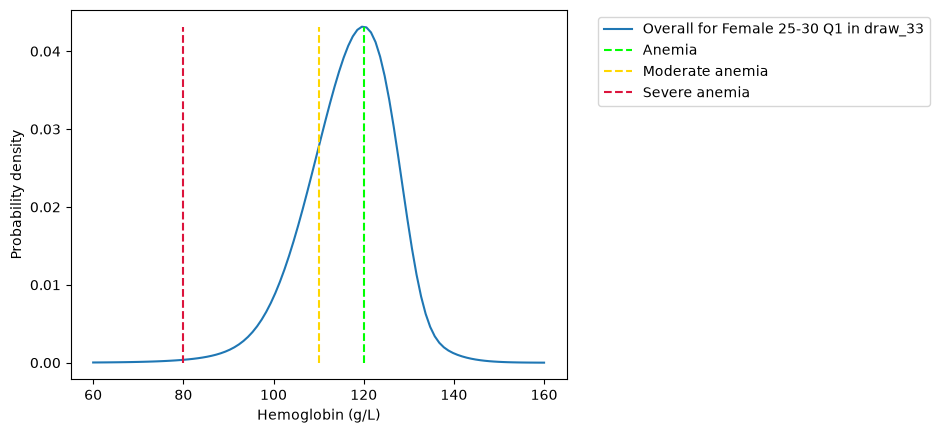

In [83]:
plot_example_distributions({"Overall": hemoglobin_distributions_by_age_sex_quintile})

In [84]:
# Assumption: non-iron-responsive anemias have same distribution of hemoglobin
# as iron-responsive anemias
non_iron_responsive_hemoglobin_distributions = truncate_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    truncate_max=hgb_info.hgb_upper_mild,
)

In [85]:
# Use even more wiggle room, as the issues in the previous check are "magnified"!
test_pdfs_cdfs_consistency(
    non_iron_responsive_hemoglobin_distributions,
    mean_tolerance=0.01,
    max_tolerance=0.10,
)

count    3.069000e+03
mean     2.114064e-03
std      6.867987e-03
min     -3.252178e-07
25%      1.113821e-05
50%      1.474619e-04
75%      9.595584e-04
max      5.784682e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  1.000000   2.0      4                draw_192   -3.252178e-07
Male    0.076712   0.5      2                draw_199   -3.095758e-07
Female  1.000000   2.0      1                draw_230   -3.018851e-07
                            4                draw_229   -2.823679e-07
        0.076712   0.5      3                draw_107   -2.680701e-07
                                                             ...     
Male    90.000000  95.0     1                draw_156    5.473739e-02
        95.000000  125.0    1                draw_218    5.574977e-02
        90.000000  95.0     1                draw_108    5.577978e-02
        95.000000  125.0    1                draw_242    5.724186e-02
        90.000000  95.0     1                draw_204    5.784682e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.002063
std         0.006881
min        -0.000230
25%        -0.000018
50%         0.000093
75%         0.000916
max         0.057851
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000230
Male    0.500000   1.0      5                draw_192   -0.000227
Female  0.076712   0.5      2                draw_238   -0.000224
Male    0.500000   1.0      5                draw_228   -0.000224
Female  1.000000   2.0      4                draw_192   -0.000224
                                                           ...   
Male    90.000000  95.0     1                draw_156    0.054742
        95.000000  125.0    1                draw_218    0.055755
        90.000000  95.0     1                draw_108    0.055785
        95.000000  125.0    1                draw_242    0.057246
        90.000000  95.0     1                draw_204    0.057851
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000436
std         0.007885
min        -0.017599
25%        -0.004109
50%        -0.001436
75%         0.000165
max         0.057856
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.017599
                            4                draw_238   -0.016117
Female  10.0       15.0     4                draw_139   -0.015907
Male    10.0       15.0     5                draw_31    -0.014506
        5.0        10.0     5                draw_91    -0.013368
                                                           ...   
        90.0       95.0     1                draw_156    0.054747
        95.0       125.0    1                draw_218    0.055759
        90.0       95.0     1                draw_108    0.055789
        95.0       125.0    1                draw_242    0.057251
        90.0       95.0     1                draw_204    0.057856
Length: 3069, dtype: float64

count    3069.000000
mean       -0.003045
std         0.008465
min        -0.054674
25%        -0.006321
50%        -0.004062
75%        -0.001782
max         0.056417
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.0        0.019178    5                draw_225   -0.054674
      35.0       40.000000   4                draw_84    -0.049001
      40.0       45.000000   3                draw_84    -0.047409
      65.0       70.000000   5                draw_229   -0.042936
      0.0        0.019178    5                draw_151   -0.042811
                                                            ...   
      90.0       95.000000   1                draw_156    0.053194
      95.0       125.000000  1                draw_218    0.054245
      90.0       95.000000   1                draw_108    0.054276
      95.0       125.000000  1                draw_242    0.055791
      90.0       95.000000   1                draw_204    0.056417
Length: 3069, dtype: float64

count    3069.000000
mean       -0.003045
std         0.008465
min        -0.054674
25%        -0.006321
50%        -0.004062
75%        -0.001782
max         0.056417
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.0        0.019178    5                draw_225   -0.054674
      35.0       40.000000   4                draw_84    -0.049001
      40.0       45.000000   3                draw_84    -0.047409
      65.0       70.000000   5                draw_229   -0.042936
      0.0        0.019178    5                draw_151   -0.042811
                                                            ...   
      90.0       95.000000   1                draw_156    0.053194
      95.0       125.000000  1                draw_218    0.054245
      90.0       95.000000   1                draw_108    0.054276
      95.0       125.000000  1                draw_242    0.055791
      90.0       95.000000   1                draw_204    0.056417
Length: 3069, dtype: float64

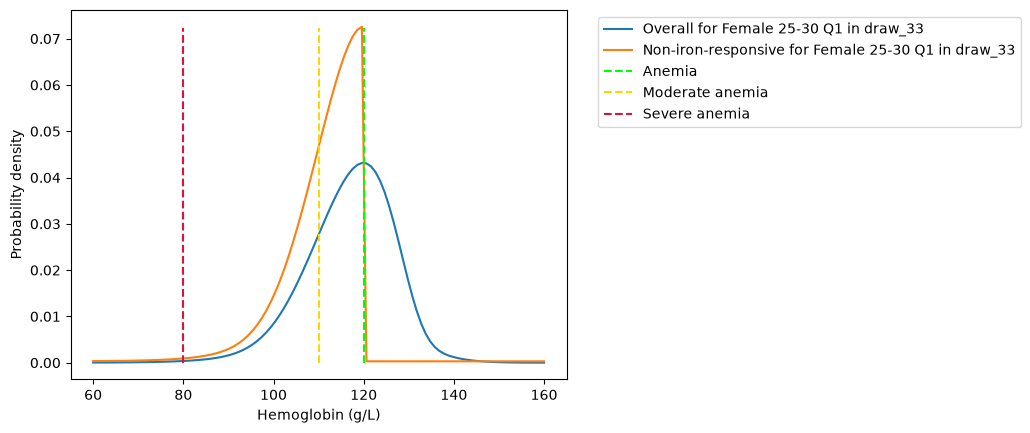

In [86]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    }
)

In [87]:
gbd_hemoglobin_distributions = distributions_from_mean_sd(
    gbd_hgb_mean, gbd_hgb_sd.loc[gbd_hgb_mean.index]
)

In [88]:
gbd_anemia_prevalence = gbd_hemoglobin_distributions.cdfs(
    thresholds.hgb_upper_mild.reindex(gbd_hgb_mean.index)
)
gbd_anemia_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.626276
                               draw_1      0.768911
                               draw_2      0.831913
                               draw_3      0.784510
                               draw_4      0.808747
                                             ...   
Male    95.0       125.000000  draw_245    0.716253
                               draw_246    0.616403
                               draw_247    0.655091
                               draw_248    0.651946
                               draw_249    0.922855
Length: 12500, dtype: float64

In [89]:
non_iron_responsive_anemia_proportion = (
    non_iron_responsive_prevalence / gbd_anemia_prevalence
)
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.106561
                               draw_1      0.106754
                               draw_2      0.081181
                               draw_3      0.077470
                               draw_4      0.091005
                                             ...   
Male    95.0       125.000000  draw_245    0.136968
                               draw_246    0.156175
                               draw_247    0.132163
                               draw_248    0.174856
                               draw_249    0.105731
Length: 12500, dtype: float64

In [90]:
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.106561
                               draw_1      0.106754
                               draw_2      0.081181
                               draw_3      0.077470
                               draw_4      0.091005
                                             ...   
Male    95.0       125.000000  draw_245    0.136968
                               draw_246    0.156175
                               draw_247    0.132163
                               draw_248    0.174856
                               draw_249    0.105731
Length: 12500, dtype: float64

In [91]:
hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.671308
                                                draw_1      0.800488
                                                draw_2      0.844674
                                                draw_3      0.836578
                                                draw_4      0.822648
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.728804
                                                draw_246    0.620822
                                                draw_247    0.663483
                                                draw_248    0.660021
                                                draw_249    0.938780
Length: 62500, dtype: float64

In [92]:
non_iron_responsive_anemia_prevalence_by_age_sex_quintile = (
    (
        non_iron_responsive_anemia_proportion
        * hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)
    )
    .reorder_levels(hgb_info.index.names)
    .reindex(hgb_info.index)
)
non_iron_responsive_anemia_prevalence_by_age_sex_quintile

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.071535
                                                draw_1      0.085455
                                                draw_2      0.068572
                                                draw_3      0.064810
                                                draw_4      0.074865
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.099823
                                                draw_246    0.096957
                                                draw_247    0.087688
                                                draw_248    0.115409
                                                draw_249    0.099258
Length: 62500, dtype: float64

In [93]:
iron_responsive_distributions = delete_from_mixture_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    non_iron_responsive_hemoglobin_distributions,
    non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
)

In [94]:
test_pdfs_cdfs_consistency(
    iron_responsive_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.102505e-03
std      4.026489e-03
min     -4.231512e-07
25%      4.688787e-06
50%      6.050234e-05
75%      3.634648e-04
max      3.682300e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.000000  15.0     1                draw_217   -4.231512e-07
Female  1.000000   2.0      4                draw_192   -2.947492e-07
Male    0.076712   0.5      2                draw_199   -2.746134e-07
Female  1.000000   2.0      1                draw_230   -2.667464e-07
                            4                draw_229   -2.484453e-07
                                                             ...     
Male    95.000000  125.0    2                draw_15     3.293308e-02
                            1                draw_218    3.324938e-02
        90.000000  95.0     1                draw_108    3.363498e-02
        95.000000  125.0    1                draw_242    3.546662e-02
        90.000000  95.0     1                draw_204    3.682300e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001076
std         0.004033
min        -0.000215
25%        -0.000008
50%         0.000034
75%         0.000336
max         0.036826
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000215
Male    0.500000   1.0      5                draw_228   -0.000205
                                             draw_192   -0.000205
Female  1.000000   2.0      4                draw_192   -0.000203
        0.076712   0.5      2                draw_238   -0.000200
                                                           ...   
Male    95.000000  125.0    2                draw_15     0.032936
                            1                draw_218    0.033252
        90.000000  95.0     1                draw_108    0.033638
        95.000000  125.0    1                draw_242    0.035469
        90.000000  95.0     1                draw_204    0.036826
Length: 3069, dtype: float64

count    3069.000000
mean        0.001495
std         0.003965
min        -0.000680
25%         0.000228
50%         0.000649
75%         0.001066
max         0.036829
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    5                draw_144   -0.000680
                                                draw_199   -0.000636
                               4                draw_148   -0.000468
        65.000000  70.000000   4                draw_139   -0.000457
Female  0.019178   0.076712    5                draw_99    -0.000379
                                                              ...   
Male    95.000000  125.000000  2                draw_15     0.032940
                               1                draw_218    0.033255
        90.000000  95.000000   1                draw_108    0.033641
        95.000000  125.000000  1                draw_242    0.035472
        90.000000  95.000000   1                draw_204    0.036829
Length: 3069, dtype: float64

count    3069.000000
mean        0.001740
std         0.003952
min         0.000041
25%         0.000590
50%         0.000831
75%         0.001227
max         0.036993
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  75.000000  80.000000   5                draw_84     0.000041
      80.000000  85.000000   5                draw_139    0.000050
                             2                draw_139    0.000052
      0.500000   1.000000    2                draw_228    0.000062
      0.019178   0.076712    1                draw_99     0.000081
                                                            ...   
      95.000000  125.000000  2                draw_15     0.033099
                             1                draw_218    0.033484
      90.000000  95.000000   1                draw_108    0.033843
      95.000000  125.000000  1                draw_242    0.035680
      90.000000  95.000000   1                draw_204    0.036993
Length: 3069, dtype: float64

count    3069.000000
mean        0.001720
std         0.003954
min         0.000041
25%         0.000575
50%         0.000799
75%         0.001202
max         0.036991
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  75.000000  80.000000   5                draw_84     0.000041
      80.000000  85.000000   5                draw_139    0.000050
                             2                draw_139    0.000052
      0.500000   1.000000    2                draw_228    0.000062
      0.019178   0.076712    1                draw_99     0.000081
                                                            ...   
      95.000000  125.000000  2                draw_15     0.033094
                             1                draw_218    0.033483
      90.000000  95.000000   1                draw_108    0.033841
      95.000000  125.000000  1                draw_242    0.035678
      90.000000  95.000000   1                draw_204    0.036991
Length: 3069, dtype: float64

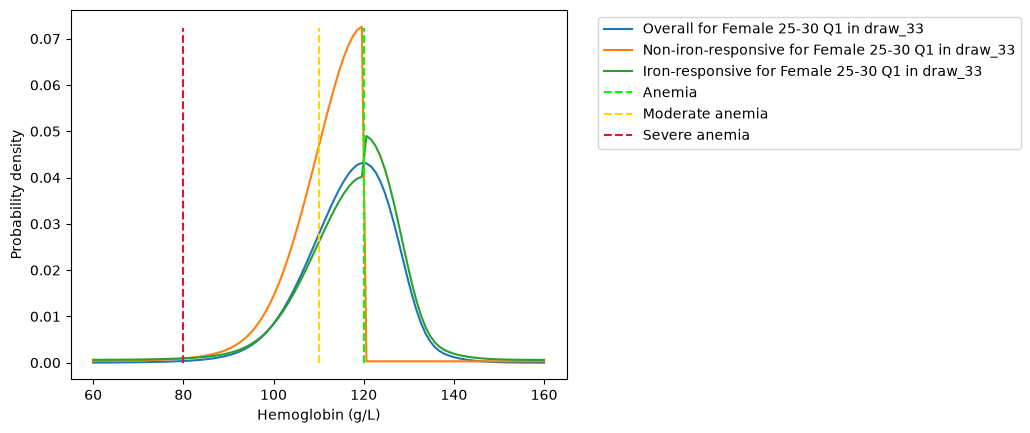

In [95]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive": iron_responsive_distributions,
    }
)

In [96]:
# NOTE: this decomposition, like what we do for wealth quintile above,
# is not exact -- we pretend that these two distributions would mix
# to the overall iron-responsive distribution, but they wouldn't.
# Here, we delete baseline coverage baked into the GBD 2021 distribution
# to get the without-fortification distribution.
# Also note that this and the next shift both assume that the hemoglobin effect among
# the responsive is a fixed value without individual-level variation.
iron_responsive_without_fortification_distributions = shift_distributions(
    iron_responsive_distributions,
    -effective_coverage_2021 * hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [97]:
test_pdfs_cdfs_consistency(
    iron_responsive_without_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.102505e-03
std      4.026489e-03
min     -4.231512e-07
25%      4.688787e-06
50%      6.050234e-05
75%      3.634648e-04
max      3.682300e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.000000  15.0     1                draw_217   -4.231512e-07
Female  1.000000   2.0      4                draw_192   -2.947492e-07
Male    0.076712   0.5      2                draw_199   -2.746134e-07
Female  1.000000   2.0      1                draw_230   -2.667464e-07
                            4                draw_229   -2.484453e-07
                                                             ...     
Male    95.000000  125.0    2                draw_15     3.293308e-02
                            1                draw_218    3.324938e-02
        90.000000  95.0     1                draw_108    3.363498e-02
        95.000000  125.0    1                draw_242    3.546662e-02
        90.000000  95.0     1                draw_204    3.682300e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001076
std         0.004033
min        -0.000215
25%        -0.000008
50%         0.000034
75%         0.000336
max         0.036826
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000215
Male    0.500000   1.0      5                draw_228   -0.000205
                                             draw_192   -0.000205
Female  1.000000   2.0      4                draw_192   -0.000203
        0.076712   0.5      2                draw_238   -0.000200
                                                           ...   
Male    95.000000  125.0    2                draw_15     0.032936
                            1                draw_218    0.033252
        90.000000  95.0     1                draw_108    0.033638
        95.000000  125.0    1                draw_242    0.035469
        90.000000  95.0     1                draw_204    0.036826
Length: 3069, dtype: float64

count    3069.000000
mean        0.001495
std         0.003965
min        -0.000680
25%         0.000228
50%         0.000649
75%         0.001066
max         0.036829
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    5                draw_144   -0.000680
                                                draw_199   -0.000636
                               4                draw_148   -0.000468
        65.000000  70.000000   4                draw_139   -0.000457
Female  0.019178   0.076712    5                draw_99    -0.000379
                                                              ...   
Male    95.000000  125.000000  2                draw_15     0.032940
                               1                draw_218    0.033255
        90.000000  95.000000   1                draw_108    0.033641
        95.000000  125.000000  1                draw_242    0.035472
        90.000000  95.000000   1                draw_204    0.036829
Length: 3069, dtype: float64

count    3069.000000
mean        0.001740
std         0.003952
min         0.000041
25%         0.000590
50%         0.000831
75%         0.001227
max         0.036993
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  75.000000  80.000000   5                draw_84     0.000041
      80.000000  85.000000   5                draw_139    0.000050
                             2                draw_139    0.000052
      0.500000   1.000000    2                draw_228    0.000062
      0.019178   0.076712    1                draw_99     0.000081
                                                            ...   
      95.000000  125.000000  2                draw_15     0.033099
                             1                draw_218    0.033484
      90.000000  95.000000   1                draw_108    0.033843
      95.000000  125.000000  1                draw_242    0.035680
      90.000000  95.000000   1                draw_204    0.036993
Length: 3069, dtype: float64

count    3069.000000
mean        0.001720
std         0.003954
min         0.000041
25%         0.000575
50%         0.000799
75%         0.001202
max         0.036991
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  75.000000  80.000000   5                draw_84     0.000041
      80.000000  85.000000   5                draw_139    0.000050
                             2                draw_139    0.000052
      0.500000   1.000000    2                draw_228    0.000062
      0.019178   0.076712    1                draw_99     0.000081
                                                            ...   
      95.000000  125.000000  2                draw_15     0.033094
                             1                draw_218    0.033483
      90.000000  95.000000   1                draw_108    0.033841
      95.000000  125.000000  1                draw_242    0.035678
      90.000000  95.000000   1                draw_204    0.036991
Length: 3069, dtype: float64

In [98]:
iron_responsive_with_fortification_distributions = shift_distributions(
    iron_responsive_without_fortification_distributions,
    hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [99]:
test_pdfs_cdfs_consistency(
    iron_responsive_with_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.107266e-03
std      4.038559e-03
min     -4.477092e-07
25%      4.916652e-06
50%      6.125603e-05
75%      3.661969e-04
max      3.691849e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.000000  15.0     1                draw_217   -4.477092e-07
Female  1.000000   2.0      4                draw_229   -1.080308e-07
        0.076712   0.5      2                draw_238   -1.037006e-07
Male    0.076712   0.5      2                draw_199   -1.033703e-07
Female  0.076712   0.5      2                draw_229   -1.014988e-07
                                                             ...     
Male    95.000000  125.0    2                draw_15     3.303415e-02
                            1                draw_218    3.332473e-02
        90.000000  95.0     1                draw_108    3.371086e-02
        95.000000  125.0    1                draw_242    3.555394e-02
        90.000000  95.0     1                draw_204    3.691849e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001085
std         0.004044
min        -0.000189
25%        -0.000004
50%         0.000037
75%         0.000340
max         0.036922
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.5        1.0      2                draw_228   -0.000189
Female  0.5        1.0      2                draw_118   -0.000183
        1.0        2.0      3                draw_208   -0.000168
                            4                draw_192   -0.000155
Male    1.0        2.0      3                draw_118   -0.000155
                                                           ...   
        95.0       125.0    2                draw_15     0.033038
                            1                draw_218    0.033328
        90.0       95.0     1                draw_108    0.033714
        95.0       125.0    1                draw_242    0.035557
        90.0       95.0     1                draw_204    0.036922
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000074
std         0.004526
min        -0.015011
25%        -0.001640
50%        -0.000707
75%         0.000044
max         0.036924
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     2                draw_91    -0.015011
        10.0       15.0     1                draw_217   -0.014532
Female  5.0        10.0     1                draw_199   -0.013132
Male    10.0       15.0     3                draw_131   -0.010861
        5.0        10.0     1                draw_186   -0.010298
                                                           ...   
        95.0       125.0    2                draw_15     0.033041
                            1                draw_218    0.033330
        90.0       95.0     1                draw_108    0.033717
        95.0       125.0    1                draw_242    0.035560
        90.0       95.0     1                draw_204    0.036924
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000413
std         0.004514
min        -0.015428
25%        -0.001788
50%        -0.001098
75%        -0.000392
max         0.036702
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     2                draw_91    -0.015428
        10.0       15.0     1                draw_217   -0.014433
Female  5.0        10.0     1                draw_199   -0.013436
Male    10.0       15.0     3                draw_131   -0.012912
        5.0        10.0     1                draw_186   -0.010849
                                                           ...   
        95.0       125.0    2                draw_15     0.032844
                            1                draw_218    0.032990
        90.0       95.0     1                draw_108    0.033417
        95.0       125.0    1                draw_242    0.035265
        90.0       95.0     1                draw_204    0.036702
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000441
std         0.004515
min        -0.015428
25%        -0.001811
50%        -0.001133
75%        -0.000425
max         0.036700
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    5.0        10.0     2                draw_91    -0.015428
        10.0       15.0     1                draw_217   -0.014439
Female  5.0        10.0     1                draw_199   -0.013436
Male    10.0       15.0     3                draw_131   -0.012912
        5.0        10.0     1                draw_186   -0.010849
                                                           ...   
        95.0       125.0    2                draw_15     0.032841
                            1                draw_218    0.032990
        90.0       95.0     1                draw_108    0.033417
        95.0       125.0    1                draw_242    0.035264
        90.0       95.0     1                draw_204    0.036700
Length: 3069, dtype: float64

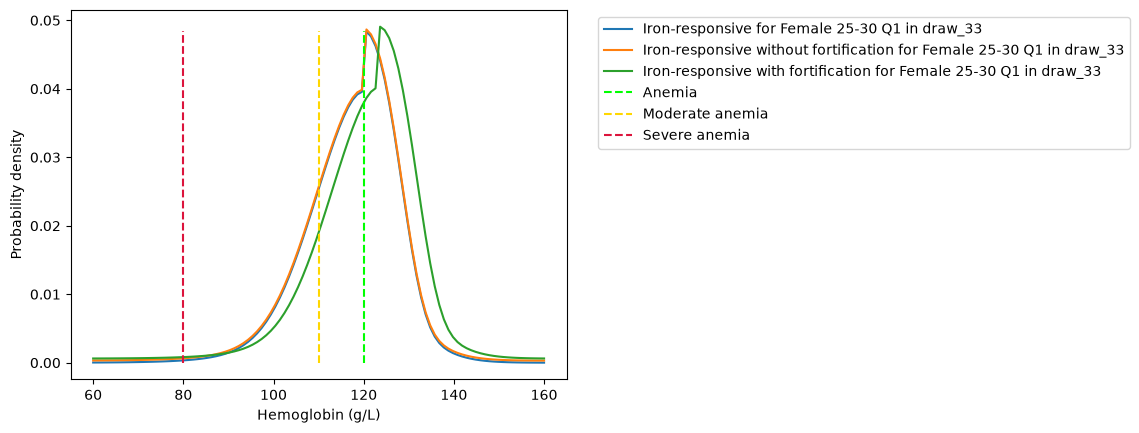

In [100]:
plot_example_distributions(
    {
        "Iron-responsive": iron_responsive_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

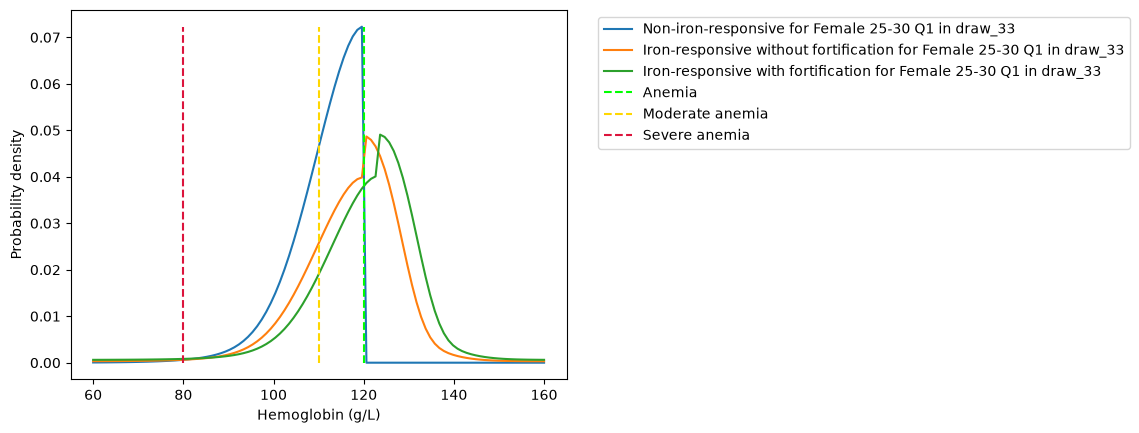

In [101]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

In [102]:
zero_fort_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
    ]
)

In [103]:
test_pdfs_cdfs_consistency(
    zero_fort_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.212899e-03
std      4.322286e-03
min     -2.978657e-07
25%      5.495763e-06
50%      7.175026e-05
75%      4.295605e-04
max      3.890249e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  1.000000   2.0      4                draw_192   -2.978657e-07
Male    0.076712   0.5      2                draw_199   -2.791810e-07
Female  1.000000   2.0      1                draw_230   -2.700983e-07
                            4                draw_229   -2.521428e-07
        0.076712   0.5      3                draw_107   -2.307220e-07
                                                             ...     
Male    90.000000  95.0     1                draw_156    3.477453e-02
        95.000000  125.0    1                draw_218    3.612713e-02
        90.000000  95.0     1                draw_108    3.616710e-02
        95.000000  125.0    1                draw_242    3.810529e-02
        90.000000  95.0     1                draw_204    3.890249e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001184
std         0.004330
min        -0.000216
25%        -0.000010
50%         0.000040
75%         0.000402
max         0.038905
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000216
Male    0.500000   1.0      5                draw_192   -0.000207
                                             draw_228   -0.000207
Female  1.000000   2.0      4                draw_192   -0.000205
        0.076712   0.5      2                draw_238   -0.000204
                                                           ...   
Male    90.000000  95.0     1                draw_156    0.034778
        95.000000  125.0    1                draw_218    0.036130
        90.000000  95.0     1                draw_108    0.036170
        95.000000  125.0    1                draw_242    0.038108
        90.000000  95.0     1                draw_204    0.038905
Length: 3069, dtype: float64

count    3069.000000
mean        0.001245
std         0.004317
min        -0.000700
25%         0.000047
50%         0.000166
75%         0.000482
max         0.038909
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.019178   0.076712    5                draw_144   -0.000700
                                              draw_199   -0.000655
      65.000000  70.000000   4                draw_139   -0.000558
                             5                draw_229   -0.000519
      0.019178   0.076712    4                draw_148   -0.000473
                                                            ...   
      90.000000  95.000000   1                draw_156    0.034781
      95.000000  125.000000  1                draw_218    0.036133
      90.000000  95.000000   1                draw_108    0.036173
      95.000000  125.000000  1                draw_242    0.038111
      90.000000  95.000000   1                draw_204    0.038909
Length: 3069, dtype: float64

count    3069.000000
mean        0.001235
std         0.004322
min        -0.000168
25%         0.000015
50%         0.000113
75%         0.000460
max         0.038915
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_225   -1.682039e-04
                                                draw_151   -5.595058e-05
        0.019178   0.076712    5                draw_144   -2.172706e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
        10.000000  15.000000   4                draw_139    1.731948e-14
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478668e-02
        95.000000  125.000000  1                draw_218    3.613931e-02
        90.000000  95.000000   1                draw_108    3.617928e-02
        95.000000  125.000000  1                draw_242    3.811745e-02
        90.000000  95.000000   1                draw_204    3.891462e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.216102e-03
std      4.324576e-03
min     -4.951595e-13
25%      6.218690e-06
50%      7.366677e-05
75%      4.336176e-04
max      3.891231e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    5                draw_144   -4.951595e-13
        65.000000  70.000000   5                draw_229   -2.475797e-13
        0.000000   0.019178    1                draw_3     -1.221245e-13
        0.019178   0.076712    5                draw_199   -1.205702e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478609e-02
        95.000000  125.000000  1                draw_218    3.613813e-02
        90.000000  95.000000   1                draw_108    3.617808e-02
        95.000000  125.000000  1                draw_242    3.811545e-02
        90.000000  95.000000   1                draw_204    3.891231e-02
Length: 3069, dtype: float64

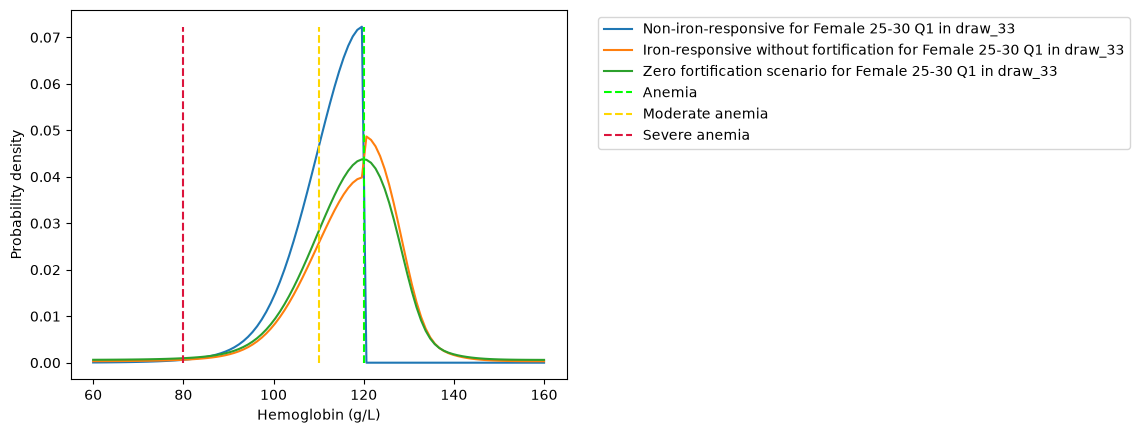

In [104]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Zero fortification scenario": zero_fort_scenario_distributions,
    }
)

In [105]:
baseline_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * (1 - effective_coverage_baseline),
        ),
        (
            iron_responsive_with_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * effective_coverage_baseline,
        ),
    ]
)

In [106]:
test_pdfs_cdfs_consistency(
    baseline_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.212899e-03
std      4.322286e-03
min     -2.978657e-07
25%      5.495763e-06
50%      7.175026e-05
75%      4.295605e-04
max      3.890249e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  1.000000   2.0      4                draw_192   -2.978657e-07
Male    0.076712   0.5      2                draw_199   -2.791810e-07
Female  1.000000   2.0      1                draw_230   -2.700983e-07
                            4                draw_229   -2.521428e-07
        0.076712   0.5      3                draw_107   -2.307220e-07
                                                             ...     
Male    90.000000  95.0     1                draw_156    3.477453e-02
        95.000000  125.0    1                draw_218    3.612713e-02
        90.000000  95.0     1                draw_108    3.616710e-02
        95.000000  125.0    1                draw_242    3.810529e-02
        90.000000  95.0     1                draw_204    3.890249e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001184
std         0.004330
min        -0.000216
25%        -0.000010
50%         0.000040
75%         0.000402
max         0.038905
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      4                draw_163   -0.000216
Male    0.500000   1.0      5                draw_192   -0.000207
                                             draw_228   -0.000207
Female  1.000000   2.0      4                draw_192   -0.000205
        0.076712   0.5      2                draw_238   -0.000204
                                                           ...   
Male    90.000000  95.0     1                draw_156    0.034778
        95.000000  125.0    1                draw_218    0.036130
        90.000000  95.0     1                draw_108    0.036170
        95.000000  125.0    1                draw_242    0.038108
        90.000000  95.0     1                draw_204    0.038905
Length: 3069, dtype: float64

count    3069.000000
mean        0.001245
std         0.004317
min        -0.000700
25%         0.000047
50%         0.000166
75%         0.000482
max         0.038909
dtype: float64


sex   age_start  age_end     wealth_quintile  draw    
Male  0.019178   0.076712    5                draw_144   -0.000700
                                              draw_199   -0.000655
      65.000000  70.000000   4                draw_139   -0.000558
                             5                draw_229   -0.000519
      0.019178   0.076712    4                draw_148   -0.000473
                                                            ...   
      90.000000  95.000000   1                draw_156    0.034781
      95.000000  125.000000  1                draw_218    0.036133
      90.000000  95.000000   1                draw_108    0.036173
      95.000000  125.000000  1                draw_242    0.038111
      90.000000  95.000000   1                draw_204    0.038909
Length: 3069, dtype: float64

count    3069.000000
mean        0.001235
std         0.004322
min        -0.000168
25%         0.000015
50%         0.000113
75%         0.000460
max         0.038915
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_225   -1.682039e-04
                                                draw_151   -5.595058e-05
        0.019178   0.076712    5                draw_144   -2.172706e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
        10.000000  15.000000   4                draw_139    1.731948e-14
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478668e-02
        95.000000  125.000000  1                draw_218    3.613931e-02
        90.000000  95.000000   1                draw_108    3.617928e-02
        95.000000  125.000000  1                draw_242    3.811745e-02
        90.000000  95.000000   1                draw_204    3.891462e-02
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.216102e-03
std      4.324576e-03
min     -4.951595e-13
25%      6.218690e-06
50%      7.366677e-05
75%      4.336176e-04
max      3.891231e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.019178   0.076712    5                draw_144   -4.951595e-13
        65.000000  70.000000   5                draw_229   -2.475797e-13
        0.000000   0.019178    1                draw_3     -1.221245e-13
        0.019178   0.076712    5                draw_199   -1.205702e-13
Female  95.000000  125.000000  1                draw_139   -1.123546e-13
                                                                ...     
Male    90.000000  95.000000   1                draw_156    3.478609e-02
        95.000000  125.000000  1                draw_218    3.613813e-02
        90.000000  95.000000   1                draw_108    3.617808e-02
        95.000000  125.000000  1                draw_242    3.811545e-02
        90.000000  95.000000   1                draw_204    3.891231e-02
Length: 3069, dtype: float64

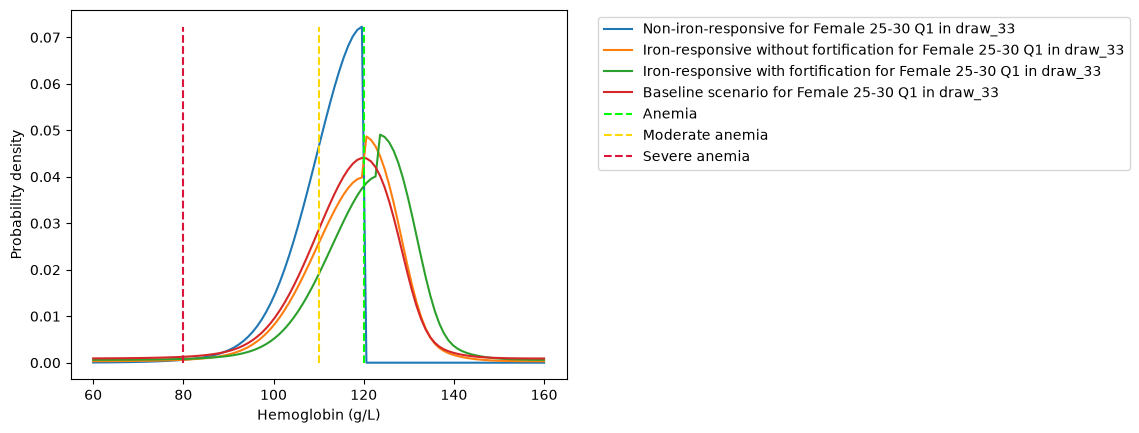

In [107]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
        "Baseline scenario": baseline_scenario_distributions,
    }
)

In [108]:
intervention_scenario_distributions = {}

for intervention_scenario in intervention_scenarios:
    effective_coverage_for_scenario = (
        effective_coverage_intervention[
            effective_coverage_intervention.index.get_level_values("scenario")
            == intervention_scenario
        ]
        .droplevel("scenario")
        .reindex(hgb_info.index)
    )
    intervention_scenario_distributions[intervention_scenario] = mix_distributions(
        [
            (
                non_iron_responsive_hemoglobin_distributions,
                non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
            ),
            (
                iron_responsive_without_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * (1 - effective_coverage_for_scenario),
            ),
            (
                iron_responsive_with_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * effective_coverage_for_scenario,
            ),
        ]
    )

In [109]:
for _, dists in intervention_scenario_distributions.items():
    test_pdfs_cdfs_consistency(
        dists,
        mean_tolerance=0.005,
        max_tolerance=0.05,
    )

count    3.069000e+03
mean     1.214288e-03
std      4.325709e-03
min     -2.346391e-07
25%      5.597114e-06
50%      7.196161e-05
75%      4.300669e-04
max      3.892180e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_199   -2.346391e-07
Female  1.000000   2.0      1                draw_230   -2.313947e-07
                            4                draw_192   -2.105633e-07
                                             draw_229   -1.992531e-07
        0.076712   0.5      1                draw_183   -1.903564e-07
                                                             ...     
Male    90.000000  95.0     1                draw_156    3.478306e-02
        95.000000  125.0    1                draw_218    3.614188e-02
        90.000000  95.0     1                draw_108    3.618218e-02
        95.000000  125.0    1                draw_242    3.812251e-02
        90.000000  95.0     1                draw_204    3.892180e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.001186
std         0.004333
min        -0.000191
25%        -0.000008
50%         0.000041
75%         0.000404
max         0.038925
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.500000   1.0      2                draw_118   -0.000191
Male    0.500000   1.0      2                draw_228   -0.000189
Female  1.000000   2.0      4                draw_192   -0.000187
Male    0.076712   0.5      2                draw_199   -0.000186
Female  0.076712   0.5      2                draw_238   -0.000185
                                                           ...   
Male    90.000000  95.0     1                draw_156    0.034786
        95.000000  125.0    1                draw_218    0.036145
        90.000000  95.0     1                draw_108    0.036185
        95.000000  125.0    1                draw_242    0.038126
        90.000000  95.0     1                draw_204    0.038925
Length: 3069, dtype: float64

count    3069.000000
mean        0.000762
std         0.004463
min        -0.004242
25%        -0.000599
50%        -0.000102
75%         0.000212
max         0.038928
dtype: float64


sex   age_start  age_end  wealth_quintile  draw    
Male  5.0        10.0     5                draw_91    -0.004242
      10.0       15.0     3                draw_131   -0.004194
      5.0        10.0     4                draw_214   -0.003918
                                           draw_122   -0.003890
      10.0       15.0     5                draw_31    -0.003679
                                                         ...   
      90.0       95.0     1                draw_156    0.034789
      95.0       125.0    1                draw_218    0.036148
      90.0       95.0     1                draw_108    0.036188
      95.0       125.0    1                draw_242    0.038129
      90.0       95.0     1                draw_204    0.038928
Length: 3069, dtype: float64

count    3069.000000
mean        0.000568
std         0.004477
min        -0.004956
25%        -0.000774
50%        -0.000407
75%         0.000062
max         0.038856
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.004956
        5.0        10.0     4                draw_214   -0.004462
                            5                draw_91    -0.004437
                            4                draw_122   -0.004352
Female  10.0       15.0     4                draw_139   -0.004266
                                                           ...   
Male    90.0       95.0     1                draw_156    0.034656
        95.0       125.0    1                draw_218    0.036043
        90.0       95.0     1                draw_108    0.036095
        95.0       125.0    1                draw_242    0.038036
        90.0       95.0     1                draw_204    0.038856
Length: 3069, dtype: float64

count    3069.000000
mean        0.000547
std         0.004480
min        -0.004956
25%        -0.000789
50%        -0.000431
75%         0.000030
max         0.038854
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.004956
        5.0        10.0     4                draw_214   -0.004462
                            5                draw_91    -0.004437
                            4                draw_122   -0.004352
Female  10.0       15.0     4                draw_139   -0.004266
                                                           ...   
Male    90.0       95.0     1                draw_156    0.034656
        95.0       125.0    1                draw_218    0.036042
        90.0       95.0     1                draw_108    0.036094
        95.0       125.0    1                draw_242    0.038034
        90.0       95.0     1                draw_204    0.038854
Length: 3069, dtype: float64

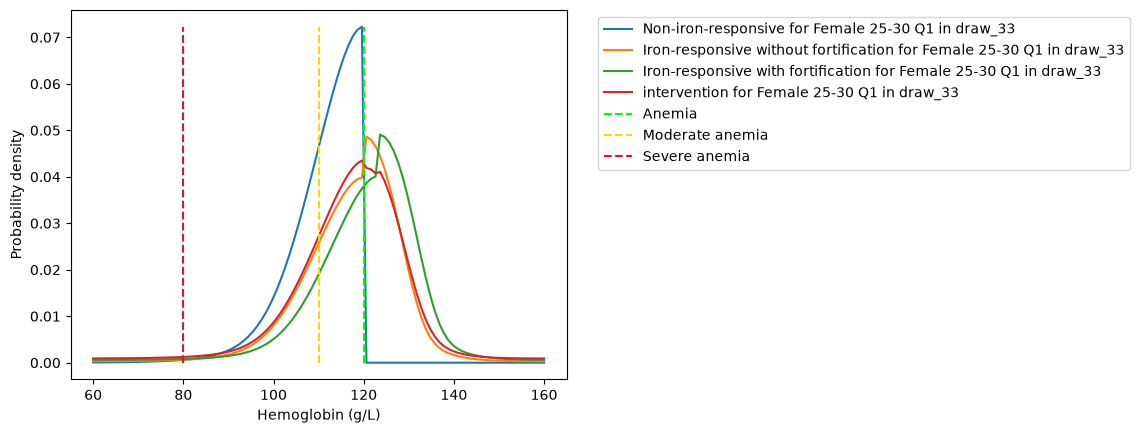

In [110]:
for intervention_scenario in intervention_scenarios:
    plot_example_distributions(
        {
            "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
            "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
            "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
            intervention_scenario: intervention_scenario_distributions[
                intervention_scenario
            ],
        }
    )
    plt.show()

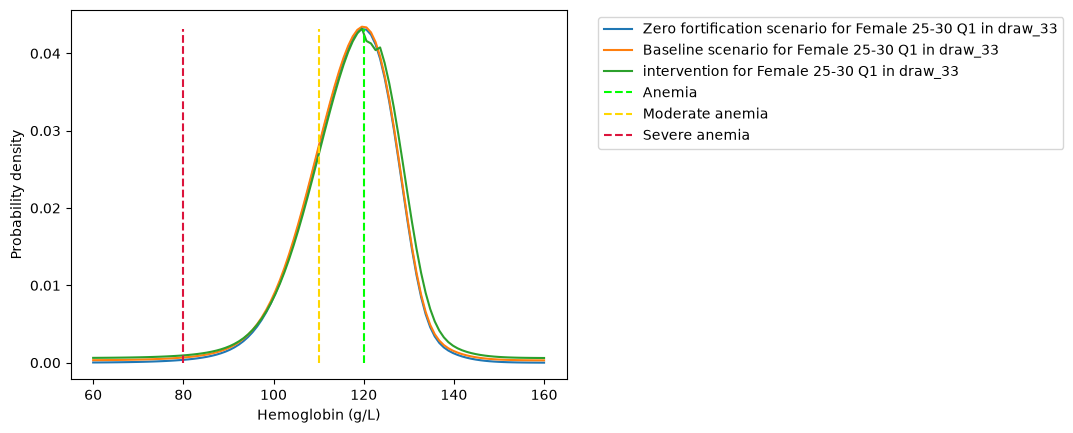

In [111]:
plot_example_distributions(
    {
        "Zero fortification scenario": zero_fort_scenario_distributions,
        "Baseline scenario": baseline_scenario_distributions,
        **intervention_scenario_distributions,
    }
)

In [112]:
def anemia_by_severity_from_distributions(distributions: Distributions):
    result = pd.DataFrame(index=distributions.data_index)
    assert result.index.equals(hgb_info.index)

    result["severe"] = distributions.cdfs(
        hgb_info.hgb_upper_severe.copy()
    ) - distributions.cdfs(hgb_info.hgb_lower_severe.copy())
    result["moderate"] = (
        distributions.cdfs(hgb_info.hgb_upper_moderate.copy()) - result["severe"]
    )
    result["mild"] = (
        distributions.cdfs(hgb_info.hgb_upper_mild.copy())
        - result["moderate"]
        - result["severe"]
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    assert (result >= 0).all().all()
    assert (result <= 1).all().all()
    return result

In [113]:
zero_fort_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    zero_fort_scenario_distributions
)
zero_fort_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.035866  0.387849   
                                            draw_1    0.048640  0.495941   
                                            draw_2    0.141564  0.519694   
                                            draw_3    0.009628  0.454075   
                                            draw_4    0.145301  0.496579   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.182477  0.307774   
                                            draw_246  0.222380  0.235417   
                                            draw_247  0.253882  0.246470   
                                            draw_248  0.251222  0.245615   
                                            draw_249  0.175955  0.488385   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.247593  0.671308  
                                            draw_1    0.255907  0.800488  
                                            draw_2    0.183416  0.844674  
                                            draw_3    0.372874  0.836578  
                                            draw_4    0.180768  0.822648  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.238553  0.728804  
                                            draw_246  0.163025  0.620822  
                                            draw_247  0.163132  0.663483  
                                            draw_248  0.163184  0.660021  
                                            draw_249  0.274440  0.938780  

[62500 rows x 4 columns]

In [114]:
baseline_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    baseline_scenario_distributions
)
baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.035866  0.387849   
                                            draw_1    0.048640  0.495941   
                                            draw_2    0.141564  0.519694   
                                            draw_3    0.009628  0.454075   
                                            draw_4    0.145301  0.496579   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.182477  0.307774   
                                            draw_246  0.222380  0.235417   
                                            draw_247  0.253882  0.246470   
                                            draw_248  0.251222  0.245615   
                                            draw_249  0.175955  0.488385   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.247593  0.671308  
                                            draw_1    0.255907  0.800488  
                                            draw_2    0.183416  0.844674  
                                            draw_3    0.372874  0.836578  
                                            draw_4    0.180768  0.822648  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.238553  0.728804  
                                            draw_246  0.163025  0.620822  
                                            draw_247  0.163132  0.663483  
                                            draw_248  0.163184  0.660021  
                                            draw_249  0.274440  0.938780  

[62500 rows x 4 columns]

In [115]:
intervention_scenarios_anemia_by_severity = {}

for scenario, distributions in intervention_scenario_distributions.items():
    anemia_by_severity = anemia_by_severity_from_distributions(distributions)
    print(scenario)
    display(anemia_by_severity)
    intervention_scenarios_anemia_by_severity[scenario] = anemia_by_severity

intervention


severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.034474  0.378894   
                                            draw_1    0.046616  0.486043   
                                            draw_2    0.137258  0.514357   
                                            draw_3    0.009129  0.437451   
                                            draw_4    0.141191  0.491556   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.175095  0.299684   
                                            draw_246  0.221518  0.226167   
                                            draw_247  0.253405  0.236321   
                                            draw_248  0.250719  0.236016   
                                            draw_249  0.162590  0.476289   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.246581  0.659950  
                                            draw_1    0.257273  0.789932  
                                            draw_2    0.185586  0.837201  
                                            draw_3    0.374600  0.821181  
                                            draw_4    0.182420  0.815166  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.238878  0.713657  
                                            draw_246  0.162645  0.610330  
                                            draw_247  0.163104  0.652831  
                                            draw_248  0.163128  0.649862  
                                            draw_249  0.288818  0.927697  

[62500 rows x 4 columns]

In [116]:
# Transform the intervention scenarios back from a dictionary to the scenario being a level
# in the MultiIndex, which is easier to work with now that we are out of function/distribution space.
intervention_scenarios_anemia_by_severity = pd.concat(
    [
        anemia_by_severity.assign(scenario=scenario).set_index("scenario", append=True)
        for scenario, anemia_by_severity in intervention_scenarios_anemia_by_severity.items()
    ]
)
intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.034474   
                                            draw_1   intervention  0.046616   
                                            draw_2   intervention  0.137258   
                                            draw_3   intervention  0.009129   
                                            draw_4   intervention  0.141191   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.175095   
                                            draw_246 intervention  0.221518   
                                            draw_247 intervention  0.253405   
                                            draw_248 intervention  0.250719   
                                            draw_249 intervention  0.162590   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.378894   
                                            draw_1   intervention  0.486043   
                                            draw_2   intervention  0.514357   
                                            draw_3   intervention  0.437451   
                                            draw_4   intervention  0.491556   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.299684   
                                            draw_246 intervention  0.226167   
                                            draw_247 intervention  0.236321   
                                            draw_248 intervention  0.236016   
                                            draw_249 intervention  0.476289   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.246581   
                                            draw_1   intervention  0.257273   
                                            draw_2   intervention  0.185586   
                                            draw_3   intervention  0.374600   
                                            draw_4   intervention  0.182420   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.238878   
                                            draw_246 intervention  0.162645   
                                            draw_247 intervention  0.163104   
                                            draw_248 intervention  0.163128   
                                            draw_249 intervention  0.288818   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.659950  
                                            draw_1   intervention  0.789932  
                                            draw_2   intervention  0.837201  
                                            draw_3   intervention  0.821181  
                                            draw_4   intervention  0.815166  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.713657  
                                            draw_246 intervention  0.610330  
                                            draw_247 intervention  0.652831  
                                            draw_248 intervention  0.649862  
                                            draw_

In [117]:
zero_fort_scenario_anemia_by_severity - baseline_scenario_anemia_by_severity

severe  moderate  mild  \
sex    age_start age_end    wealth_quintile draw                               
Female 0.0       0.019178   1               draw_0       0.0       0.0   0.0   
                                            draw_1       0.0       0.0   0.0   
                                            draw_2       0.0       0.0   0.0   
                                            draw_3       0.0       0.0   0.0   
                                            draw_4       0.0       0.0   0.0   
...                                                      ...       ...   ...   
Male   95.0      125.000000 5               draw_245     0.0       0.0   0.0   
                                            draw_246     0.0       0.0   0.0   
                                            draw_247     0.0       0.0   0.0   
                                            draw_248     0.0       0.0   0.0   
                                            draw_249     0.0       0.0   0.0   

                                                      anemic  
sex    age_start age_end    wealth_quintile draw              
Female 0.0       0.019178   1               draw_0       0.0  
                                            draw_1       0.0  
                                            draw_2       0.0  
                                            draw_3       0.0  
                                            draw_4       0.0  
...                                                      ...  
Male   95.0      125.000000 5               draw_245     0.0  
                                            draw_246     0.0  
                                            draw_247     0.0  
                                            draw_248     0.0  
                                            draw_249     0.0  

[62500 rows x 4 columns]

In [118]:
baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.001392   
                                            draw_1   intervention  0.002024   
                                            draw_2   intervention  0.004306   
                                            draw_3   intervention  0.000500   
                                            draw_4   intervention  0.004110   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.007382   
                                            draw_246 intervention  0.000862   
                                            draw_247 intervention  0.000476   
                                            draw_248 intervention  0.000504   
                                            draw_249 intervention  0.013366   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.008955   
                                            draw_1   intervention  0.009898   
                                            draw_2   intervention  0.005337   
                                            draw_3   intervention  0.016624   
                                            draw_4   intervention  0.005023   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.008090   
                                            draw_246 intervention  0.009250   
                                            draw_247 intervention  0.010149   
                                            draw_248 intervention  0.009599   
                                            draw_249 intervention  0.012095   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.001011   
                                            draw_1   intervention -0.001367   
                                            draw_2   intervention -0.002170   
                                            draw_3   intervention -0.001726   
                                            draw_4   intervention -0.001651   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention -0.000325   
                                            draw_246 intervention  0.000380   
                                            draw_247 intervention  0.000027   
                                            draw_248 intervention  0.000056   
                                            draw_249 intervention -0.014378   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.011358  
                                            draw_1   intervention  0.010556  
                                            draw_2   intervention  0.007473  
                                            draw_3   intervention  0.015397  
                                            draw_4   intervention  0.007482  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.015147  
                                            draw_246 intervention  0.010492  
                                            draw_247 intervention  0.010653  
                                            draw_248 intervention  0.010159  
                                            draw_

<Axes: >

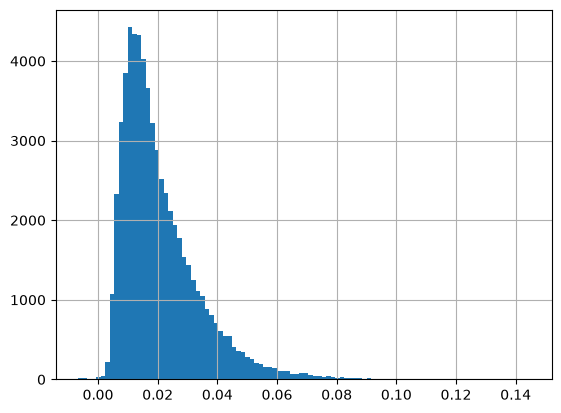

In [119]:
# We can see that in very rare cases, likely due to numerical instability, we get a negative impact
(
    baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity
).anemic.hist(bins=100)

In [120]:
def anemia_by_severity_to_yld_rates(anemia_by_severity):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia_by_severity.index
    anemia_by_severity = (
        anemia_by_severity.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia_by_severity["mild_yld_rate"] = (
        anemia_by_severity.mild * anemia_by_severity.mild_dw
    )
    anemia_by_severity["moderate_yld_rate"] = (
        anemia_by_severity.moderate * anemia_by_severity.moderate_dw
    )
    anemia_by_severity["severe_yld_rate"] = (
        anemia_by_severity.severe * anemia_by_severity.severe_dw
    )
    anemia_by_severity["anemic_yld_rate"] = (
        anemia_by_severity["mild_yld_rate"]
        + anemia_by_severity["moderate_yld_rate"]
        + anemia_by_severity["severe_yld_rate"]
    )

    return anemia_by_severity.set_index(orig_index.names).filter(like="yld_rate")

In [121]:
zero_fort_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    zero_fort_scenario_anemia_by_severity
)
zero_fort_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000599   
                            2               draw_0         0.000594   
                            3               draw_0         0.000619   
                            4               draw_0         0.000661   
                            5               draw_0         0.000654   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.001310   
                            2               draw_249       0.001352   
                            3               draw_249       0.001410   
                            4               draw_249       0.001447   
                            5               draw_249       0.001461   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.023000   
                            2               draw_0             0.021990   
                            3               draw_0             0.020566   
                            4               draw_0             0.018049   
                            5               draw_0             0.015273   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.031037   
                            2               draw_249           0.032424   
                            3               draw_249           0.034259   
                            4               draw_249           0.034951   
                            5               draw_249           0.036049   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.007135   
                            2               draw_0           0.006628   
                            3               draw_0           0.004993   
                            4               draw_0           0.003043   
                            5               draw_0           0.002151   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.044520   
                            2               draw_249         0.041591   
                            3               draw_249         0.037344   
                            4               draw_249         0.034981   
                            5               draw_249         0.033243   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.030734  
                            2               draw_0           0.029212  
                            3               draw_0           0.026178  
                            4               draw_0           0.021753  
                            5               draw_0           0.018079  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.076866  
                            2               draw_249         0.075367  
                            3               draw_249         0.073013  
                            4               draw_249         0.071379  
                            5               draw_249         0.070753  

[62500 rows x 4 columns]

In [122]:
baseline_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    baseline_scenario_anemia_by_severity
)
baseline_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000599   
                            2               draw_0         0.000594   
                            3               draw_0         0.000619   
                            4               draw_0         0.000661   
                            5               draw_0         0.000654   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.001310   
                            2               draw_249       0.001352   
                            3               draw_249       0.001410   
                            4               draw_249       0.001447   
                            5               draw_249       0.001461   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.023000   
                            2               draw_0             0.021990   
                            3               draw_0             0.020566   
                            4               draw_0             0.018049   
                            5               draw_0             0.015273   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.031037   
                            2               draw_249           0.032424   
                            3               draw_249           0.034259   
                            4               draw_249           0.034951   
                            5               draw_249           0.036049   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.007135   
                            2               draw_0           0.006628   
                            3               draw_0           0.004993   
                            4               draw_0           0.003043   
                            5               draw_0           0.002151   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.044520   
                            2               draw_249         0.041591   
                            3               draw_249         0.037344   
                            4               draw_249         0.034981   
                            5               draw_249         0.033243   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.030734  
                            2               draw_0           0.029212  
                            3               draw_0           0.026178  
                            4               draw_0           0.021753  
                            5               draw_0           0.018079  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.076866  
                            2               draw_249         0.075367  
                            3               draw_249         0.073013  
                            4               draw_249         0.071379  
                            5               draw_249         0.070753  

[62500 rows x 4 columns]

In [123]:
intervention_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    intervention_scenarios_anemia_by_severity
)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Female 0.0       0.019178   1               draw_0   intervention       0.000597   
                            2               draw_0   intervention       0.000590   
                            3               draw_0   intervention       0.000612   
                            4               draw_0   intervention       0.000647   
                            5               draw_0   intervention       0.000635   
...                                                                          ...   
Male   95.0      125.000000 1               draw_249 intervention       0.001332   
                            2               draw_249 intervention       0.001387   
                            3               draw_249 intervention       0.001462   
                            4               draw_249 intervention       0.001511   
                            5               draw_249 intervention       0.001537   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Female 0.0       0.019178   1               draw_0   intervention           0.022469   
                            2               draw_0   intervention           0.021293   
                            3               draw_0   intervention           0.019678   
                            4               draw_0   intervention           0.016972   
                            5               draw_0   intervention           0.014184   
...                                                                              ...   
Male   95.0      125.000000 1               draw_249 intervention           0.030749   
                            2               draw_249 intervention           0.032001   
                            3               draw_249 intervention           0.033652   
                            4               draw_249 intervention           0.034179   
                            5               draw_249 intervention           0.035156   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention         0.006858   
                            2               draw_0   intervention         0.006288   
                            3               draw_0   intervention         0.004675   
                            4               draw_0   intervention         0.002813   
                            5               draw_0   intervention         0.001978   
...                                                                            ...   
Male   95.0      125.000000 1               draw_249 intervention         0.043320   
                            2               draw_249 intervention         0.039938   
                            3               draw_249 intervention         0.035294   
                            4               draw_249 intervention         0.032627   
                            5               draw_249 intervention         0.030718   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Female 0.0       0.019178   1               draw_0   intervention         0.029924  
                            2               draw_0   intervention         0.028171  
                            3               draw_0   intervention         0.024965  
                            4               draw_0   intervention         0.020432  
                            5               draw_0   intervention         0.016797  
...                                                                            ...  
Male   95.0      125.000000 1 

In [124]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                      
Male   95.000000 125.0   1               draw_163 intervention  -1.050798e-07   
                                         draw_19  intervention  -2.630599e-07   
       90.000000 95.0    1               draw_163 intervention  -5.540274e-08   
       10.000000 15.0    2               draw_217 intervention  -1.441728e-05   
       90.000000 95.0    1               draw_19  intervention  -7.125274e-08   
...                                                                       ...   
       0.500000  1.0     4               draw_19  intervention  -3.238325e-05   
Female 0.500000  1.0     5               draw_19  intervention   3.636703e-05   
       0.076712  0.5     4               draw_45  intervention   3.092828e-04   
       0.500000  1.0     4               draw_19  intervention  -1.142540e-05   
Male   0.500000  1.0     5               draw_19  intervention  -1.017690e-06   

                                                                moderate_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                          
Male   95.000000 125.0   1               draw_163 intervention           0.000326   
                                         draw_19  intervention           0.000644   
       90.000000 95.0    1               draw_163 intervention           0.000314   
       10.000000 15.0    2               draw_217 intervention          -0.000243   
       90.000000 95.0    1               draw_19  intervention           0.000617   
...                                                                           ...   
       0.500000  1.0     4               draw_19  intervention           0.003921   
Female 0.500000  1.0     5               draw_19  intervention           0.004185   
       0.076712  0.5     4               draw_45  intervention           0.004092   
       0.500000  1.0     4               draw_19  intervention           0.004302   
Male   0.500000  1.0     5               draw_19  intervention           0.004259   

                                                                severe_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                        
Male   95.000000 125.0   1               draw_163 intervention        -0.000670   
                                         draw_19  intervention        -0.000981   
       90.000000 95.0    1               draw_163 intervention        -0.000608   
       10.000000 15.0    2               draw_217 intervention        -0.000014   
       90.000000 95.0    1               draw_19  intervention        -0.000881   
...                                                                         ...   
       0.500000  1.0     4               draw_19  intervention         0.000399   
Female 0.500000  1.0     5               draw_19  intervention         0.000113   
       0.076712  0.5     4               draw_45  intervention         0.000036   
       0.500000  1.0     4               draw_19  intervention         0.000167   
Male   0.500000  1.0     5               draw_19  intervention         0.000215   

                                                                anemic_yld_rate  
sex    age_start age_end wealth_quintile draw     scenario                       
Male   95.000000 125.0   1               draw_163 intervention        -0.000344  
                                         draw_19  intervention        -0.000337  
       90.000000 95.0    1               draw_163 intervention        -0.000294  
       10.000000 15.0    2               draw_217 intervention        -0.000272  
       90.000000 95.0    1               draw_19  intervention        -0.000265  
...                                                                         ...  
       0.500000  1.0     4               draw_19  intervention         0.004287  
Female 0.500000  1.0     5               draw_19  intervention         0.004335  
    

<Axes: >

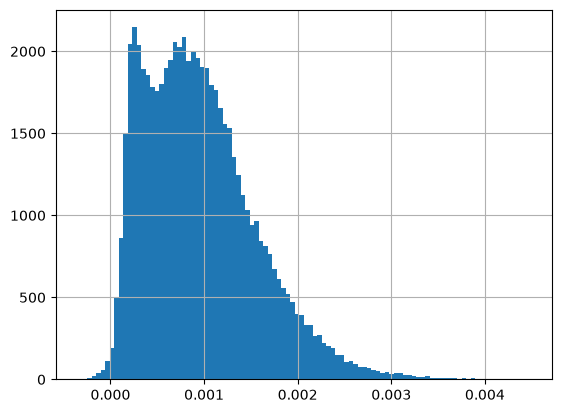

In [125]:
(
    baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates
).anemic_yld_rate.hist(bins=100)

In [126]:
zero_fort_scenario_ylds = (
    zero_fort_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  766.877919
                               2                  700.282642
                               3                  589.931789
                               4                  459.736805
                               5                  352.172009
                                                     ...    
Male    95.0       125.000000  1                  271.874317
                               2                  239.706506
                               3                  241.989523
                               4                  235.515990
                               5                  293.747487
Length: 250, dtype: float64

In [127]:
baseline_scenario_ylds = (
    baseline_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  766.877919
                               2                  700.282642
                               3                  589.931789
                               4                  459.736805
                               5                  352.172009
                                                     ...    
Male    95.0       125.000000  1                  271.874317
                               2                  239.706506
                               3                  241.989523
                               4                  235.515990
                               5                  293.747487
Length: 250, dtype: float64

In [128]:
intervention_scenarios_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_scenarios_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    750.444017
                               2                intervention    679.971004
                               3                intervention    567.761074
                               4                intervention    437.591656
                               5                intervention    332.771768
                                                                   ...    
Male    95.0       125.000000  1                intervention    269.578844
                               2                intervention    236.472995
                               3                intervention    237.149569
                               4                intervention    229.612771
                               5                intervention    285.265763
Length: 250, dtype: float64

In [129]:
(
    baseline_scenario_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_scenarios_ylds.loc[("Female", 25, 30, 1)].mean()
)

862.063665117912

In [130]:
(
    baseline_scenario_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_scenarios_ylds.groupby(["scenario", "wealth_quintile"]).sum()
)

scenario      wealth_quintile
intervention  1                  30971.808232
              2                  40301.650862
              3                  45140.827647
              4                  48713.202061
              5                  47733.081757
dtype: float64

In [131]:
ylds = pd.concat(
    [
        zero_fort_scenario_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_scenario_ylds.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_scenarios_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,766.877919,zero
1,Female,0.0,0.019178,2,700.282642,zero
2,Female,0.0,0.019178,3,589.931789,zero
3,Female,0.0,0.019178,4,459.736805,zero
4,Female,0.0,0.019178,5,352.172009,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,269.578844,intervention
746,Male,95.0,125.000000,2,236.472995,intervention
747,Male,95.0,125.000000,3,237.149569,intervention
748,Male,95.0,125.000000,4,229.612771,intervention


In [132]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [133]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [134]:
zero_fort_anemia_prevalence = (
    zero_fort_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.811667
                               2                  0.795096
                               3                  0.785996
                               4                  0.773774
                               5                  0.737130
                                                    ...   
Male    95.0       125.000000  1                  0.746718
                               2                  0.754730
                               3                  0.764545
                               4                  0.766744
                               5                  0.774427
Length: 250, dtype: float64

In [135]:
baseline_anemia_prevalence = (
    baseline_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.811667
                               2                  0.795096
                               3                  0.785996
                               4                  0.773774
                               5                  0.737130
                                                    ...   
Male    95.0       125.000000  1                  0.746718
                               2                  0.754730
                               3                  0.764545
                               4                  0.766744
                               5                  0.774427
Length: 250, dtype: float64

In [136]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15253.787430
                               2                  14177.057673
                               3                  12677.857494
                               4                  10921.063707
                               5                   8999.215869
                                                      ...     
Male    95.0       125.000000  1                   3621.319612
                               2                   3299.062359
                               3                   3493.908641
                               4                   3489.379471
                               5                   4453.463054
Length: 250, dtype: float64

In [137]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.4638767146381033

In [138]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15253.787430
                               2                  14177.057673
                               3                  12677.857494
                               4                  10921.063707
                               5                   8999.215869
                                                      ...     
Male    95.0       125.000000  1                   3621.319612
                               2                   3299.062359
                               3                   3493.908641
                               4                   3489.379471
                               5                   4453.463054
Length: 250, dtype: float64

In [139]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.4638767146381033

In [140]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.515674
2    0.501204
3    0.461289
4    0.433494
5    0.408588
dtype: float64

In [141]:
intervention_anemia_prevalence = (
    intervention_scenarios_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.802241
                               2                intervention    0.782067
                               3                intervention    0.768865
                               4                intervention    0.751345
                               5                intervention    0.711027
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.741245
                               2                intervention    0.747170
                               3                intervention    0.754888
                               4                intervention    0.755250
                               5                intervention    0.761964
Length: 250, dtype: float64

In [142]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.811667,zero
1,Female,0.0,0.019178,2,0.795096,zero
2,Female,0.0,0.019178,3,0.785996,zero
3,Female,0.0,0.019178,4,0.773774,zero
4,Female,0.0,0.019178,5,0.737130,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.741245,intervention
746,Male,95.0,125.000000,2,0.747170,intervention
747,Male,95.0,125.000000,3,0.754888,intervention
748,Male,95.0,125.000000,4,0.755250,intervention


In [143]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [144]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    15076.636696
                               2                intervention    13944.742772
                               3                intervention    12401.531295
                               4                intervention    10604.501082
                               5                intervention     8680.538411
                                                                    ...     
Male    95.0       125.000000  1                intervention     3594.777472
                               2                intervention     3266.016080
                               3                intervention     3449.778426
                               4                intervention     3437.070165
                               5                intervention     4381.796662
Length: 250, dtype: float64

In [145]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.442691122653749

In [146]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.502928
2    0.483840
3    0.439021
4    0.407725
5    0.380941
dtype: float64

In [147]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1      592,221
2      813,617
3    1,048,167
4    1,216,746
5    1,299,814
dtype: object

In [148]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,15253.787430,zero
1,Female,0.0,0.019178,2,14177.057673,zero
2,Female,0.0,0.019178,3,12677.857494,zero
3,Female,0.0,0.019178,4,10921.063707,zero
4,Female,0.0,0.019178,5,8999.215869,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,3594.777472,intervention
746,Male,95.0,125.000000,2,3266.016080,intervention
747,Male,95.0,125.000000,3,3449.778426,intervention
748,Male,95.0,125.000000,4,3437.070165,intervention


In [149]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)